In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## Load data

In [3]:
application_train = pd.read_csv('../data/application_train.csv')
application_test = pd.read_csv('../data/application_test.csv')
bureau_balance = pd.read_csv('../data/bureau_balance.csv')
bureau = pd.read_csv('../data/bureau.csv')
credit_card_balance = pd.read_csv('../data/credit_card_balance.csv')
installments_payments = pd.read_csv('../data/installments_payments.csv')
POS_CASH_balance = pd.read_csv('../data/POS_CASH_balance.csv')
previous_application = pd.read_csv('../data/previous_application.csv')

In [4]:
dfs = {
    'application_train': application_train,
    'application_test': application_test,
    'bureau_balance': bureau_balance,
    'bureau': bureau,
    'credit_card_balance': credit_card_balance,
    'installments_payments': installments_payments,
    'POS_CASH_balance': POS_CASH_balance,
    'previous_application': previous_application,
}

In [5]:
for k, v in dfs.items():
    print(f"Shape of {k}: {v.shape}")

Shape of application_train: (307511, 122)
Shape of application_test: (48744, 121)
Shape of bureau_balance: (27299925, 3)
Shape of bureau: (1716428, 17)
Shape of credit_card_balance: (3840312, 23)
Shape of installments_payments: (13605401, 8)
Shape of POS_CASH_balance: (10001358, 8)
Shape of previous_application: (1670214, 37)


## Null values

Посмотрим пропущенные значения в данных. Выведем по 25 фич с наибольшим кол-вом пропусков

In [6]:
def get_null_values_percent(df):
    null_percentages = []
    total_rows = len(df)
    for col in df.columns:
        null_percentages.append({'Column': col, 'Null percent': df[col].isnull().sum() / total_rows * 100})
    return pd.DataFrame(null_percentages).sort_values(by='Null percent', ascending=False)

Null values percents in application_train


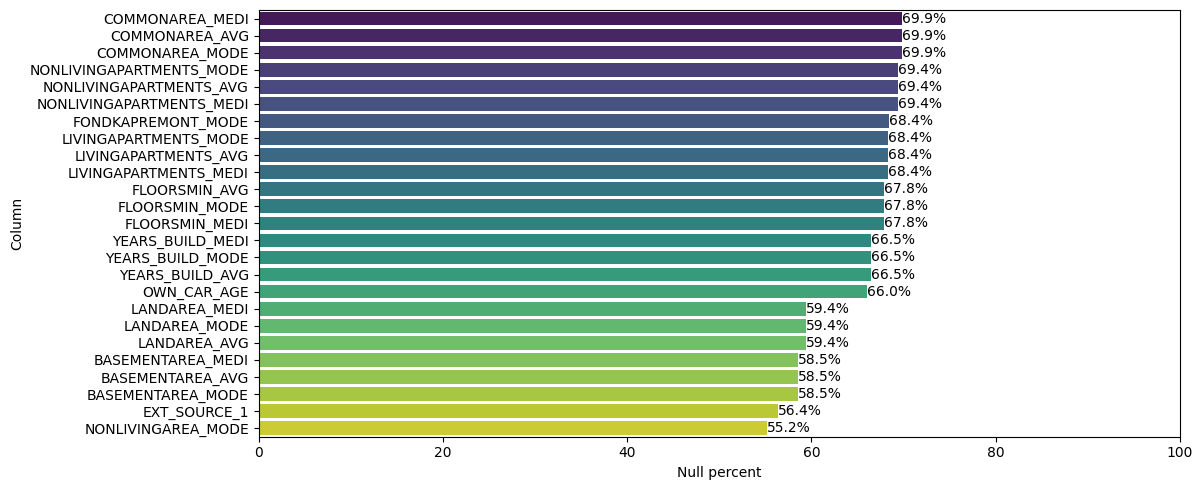

Null values percents in application_test


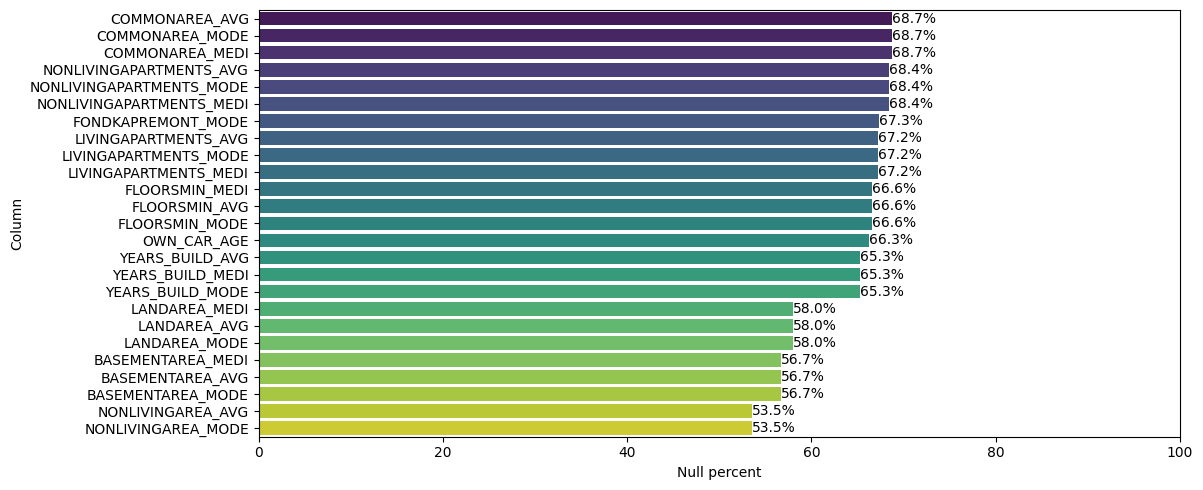

Null values percents in bureau_balance


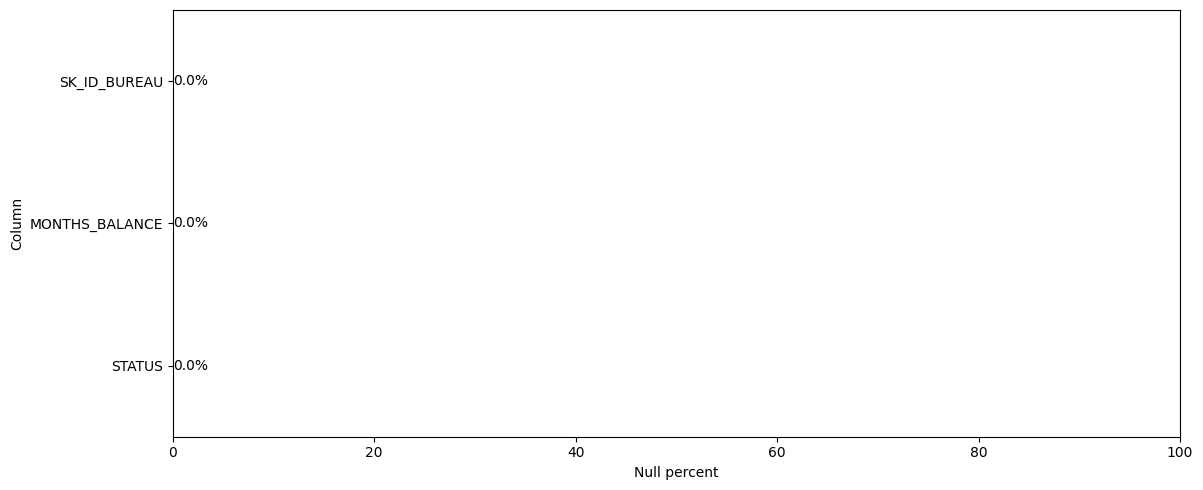

Null values percents in bureau


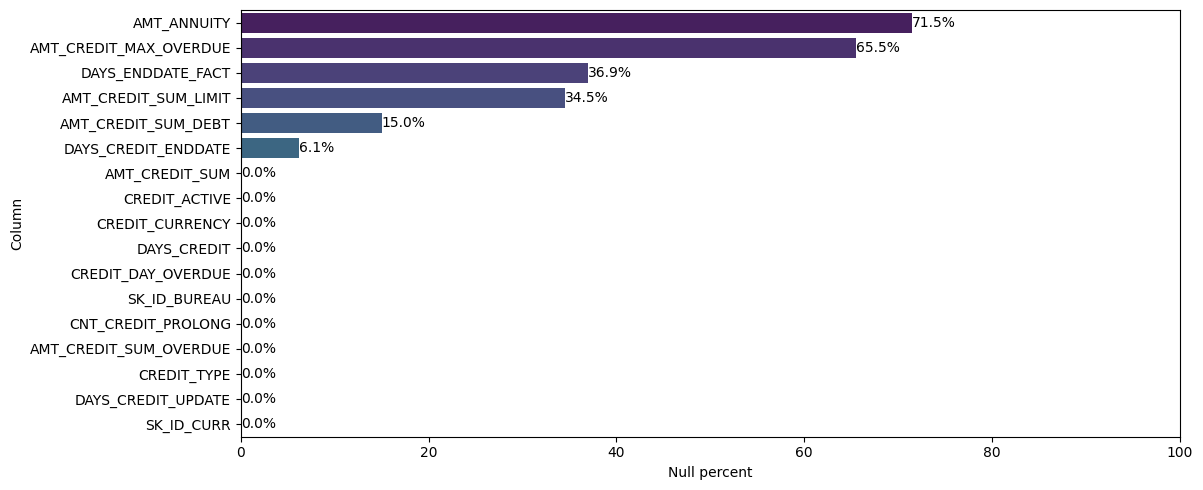

Null values percents in credit_card_balance


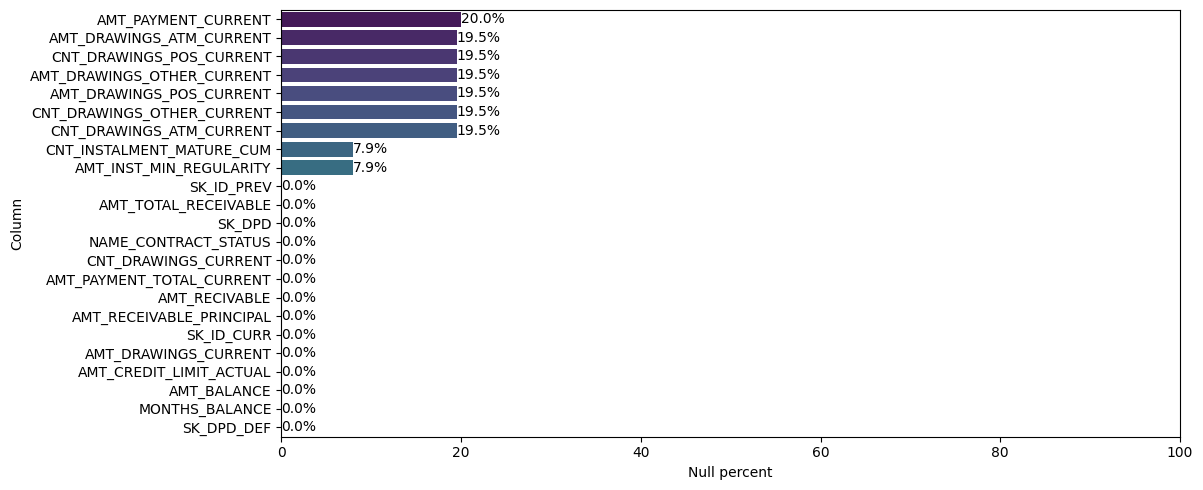

Null values percents in installments_payments


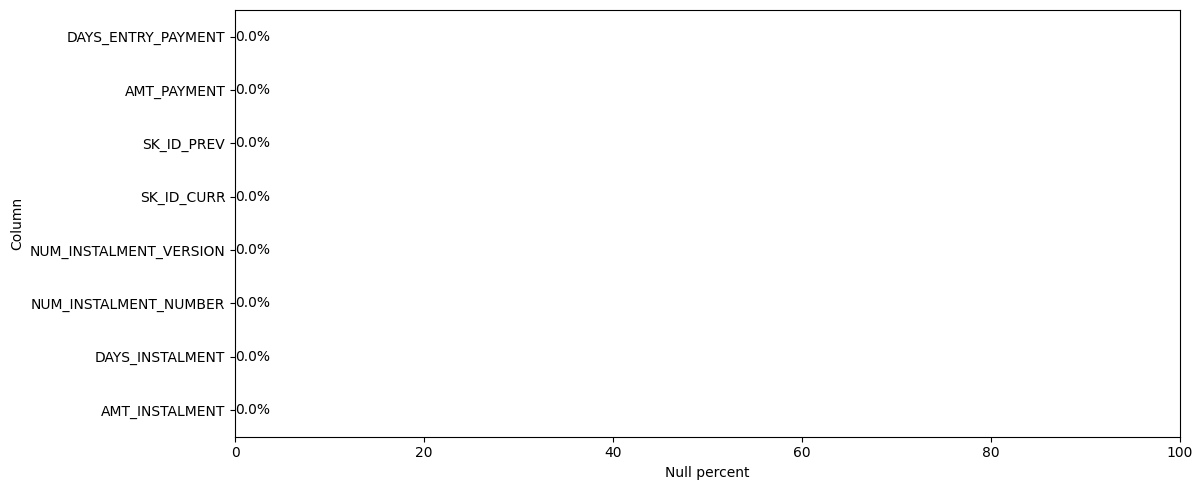

Null values percents in POS_CASH_balance


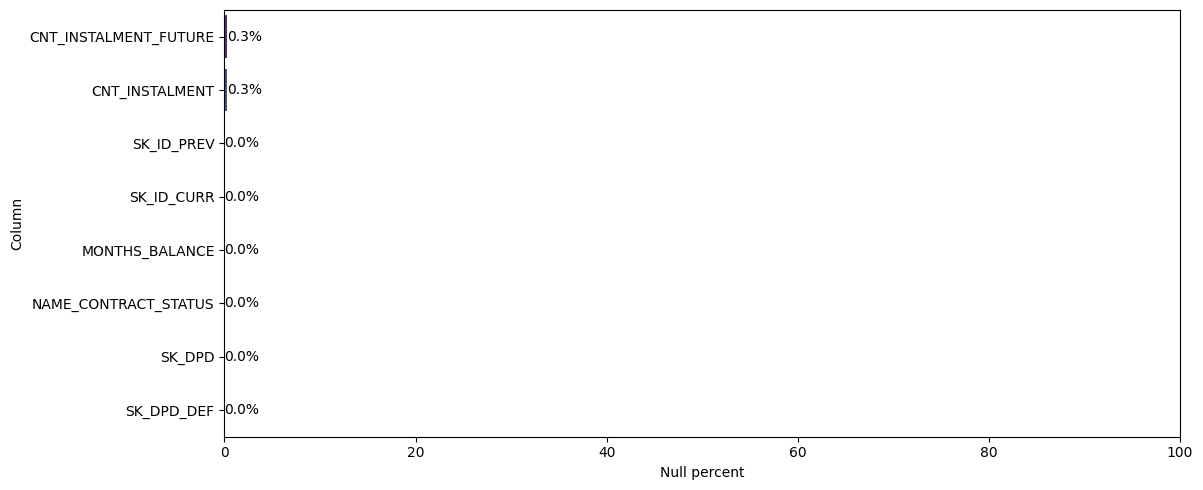

Null values percents in previous_application


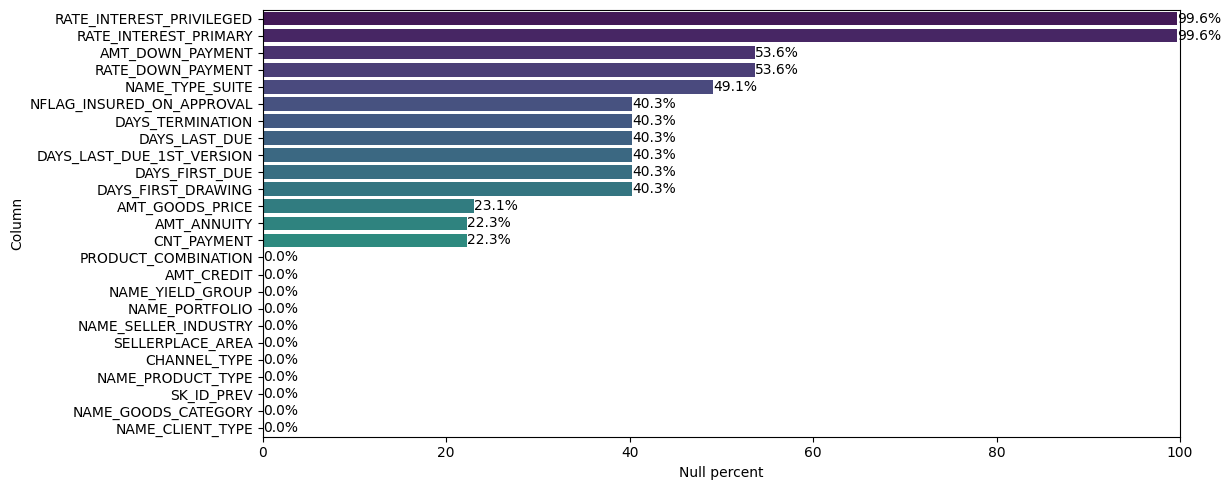

In [ ]:
for k, v in dfs.items():
    print(f'Null values percents in {k}')
    null_df = get_null_values_percent(v).head(25)
    
    plt.figure(figsize=(12, 5))
    ax = sns.barplot(
        y=null_df['Column'],
        x=null_df['Null percent']
    )

    for p in ax.patches:
        width = p.get_width()             # длина бара
        y   = p.get_y() + p.get_height()/2  # вертикальная позиция текста
        ax.annotate(
            f'{width:.1f}%',              # форматируем число, тут 1 знак после запятой и знак процента
            (width, y),                   # координаты (x, y)
            ha='left',                    # выравнивание по горизонтали
            va='center'                   # выравнивание по вертикали
        )

    plt.tight_layout()
    ax.set_xlim(0, 100)
    plt.show()
    print('=' * 50)

## Application

In [11]:
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [12]:
application_train.info(True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [ ]:
def num_col_info(data, col, target='TARGET'):
    target_0 = data[data[target] == 0][col]
    target_1 = data[data[target] == 1][col]
    sns.kdeplot(target_0, fill=True, color='blue', label='0')
    sns.kdeplot(target_1, fill=True, color='orange', label='1')
    
    plt.legend(title='TARGET')
    plt.show()

### Посмотрим как распределены целочисленные признаки в зависимости от таргета

Column:  CNT_CHILDREN


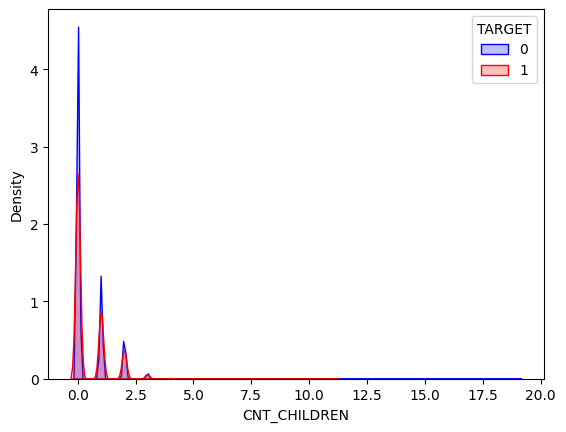

Column:  DAYS_BIRTH


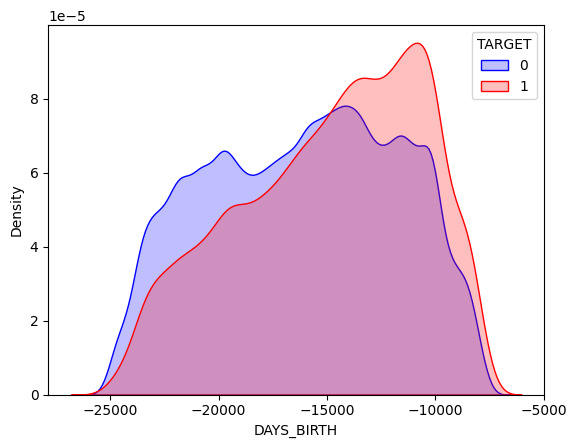

Column:  DAYS_EMPLOYED


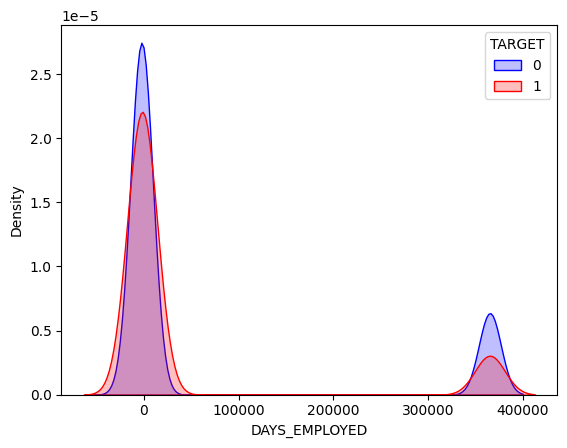

Column:  DAYS_ID_PUBLISH


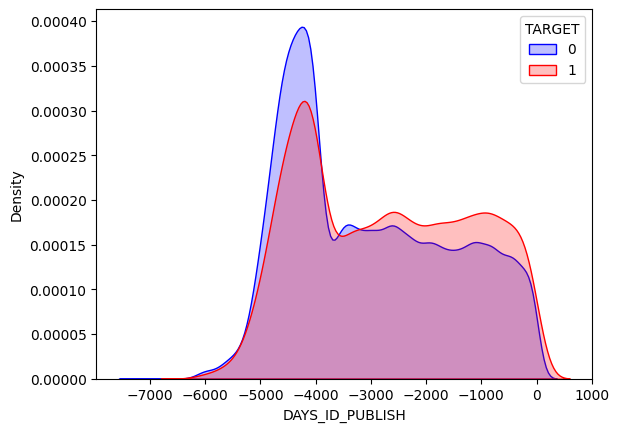

Column:  REGION_RATING_CLIENT


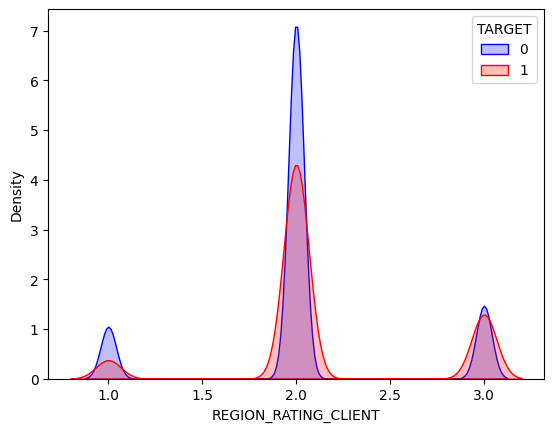

Column:  REGION_RATING_CLIENT_W_CITY


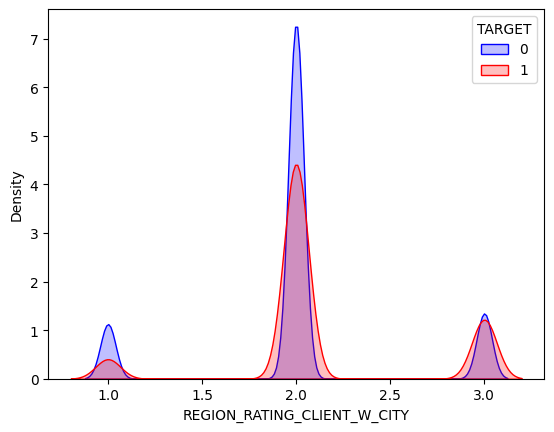

Column:  HOUR_APPR_PROCESS_START


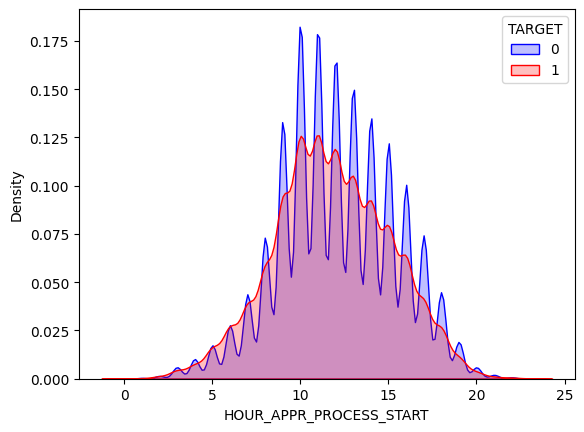

Column:  REG_REGION_NOT_LIVE_REGION


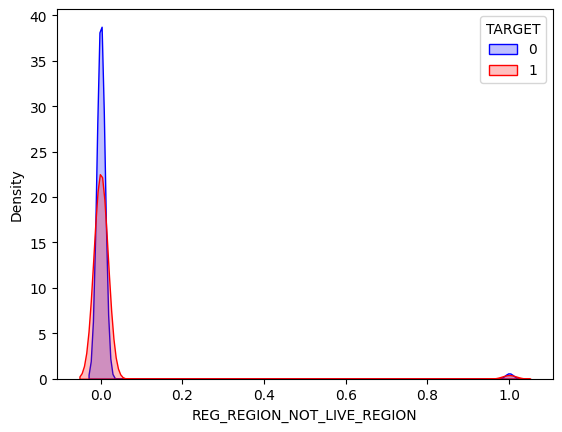

Column:  REG_REGION_NOT_WORK_REGION


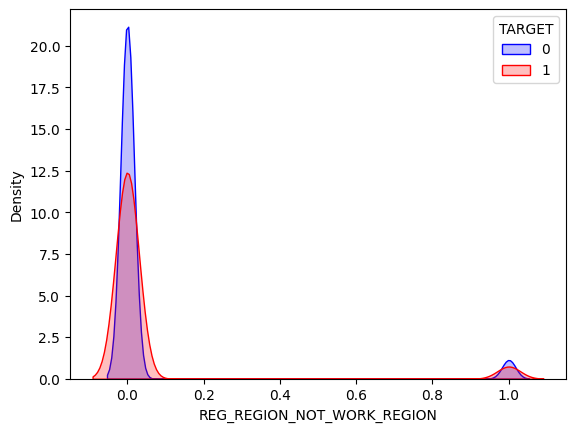

Column:  LIVE_REGION_NOT_WORK_REGION


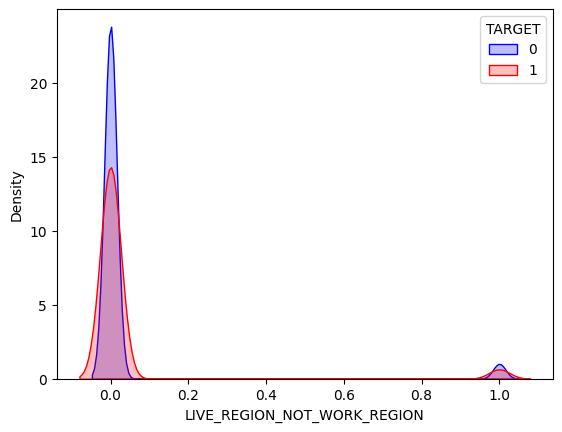

Column:  REG_CITY_NOT_LIVE_CITY


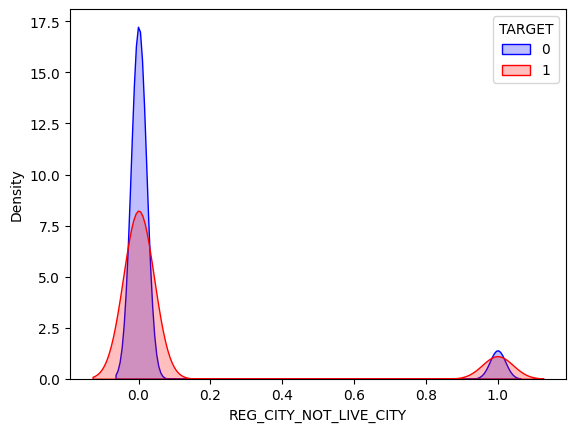

Column:  REG_CITY_NOT_WORK_CITY


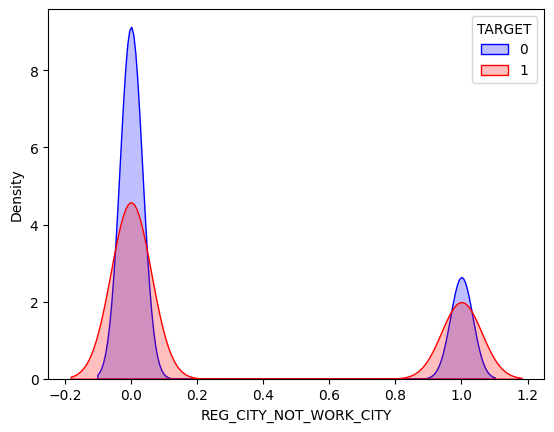

Column:  LIVE_CITY_NOT_WORK_CITY


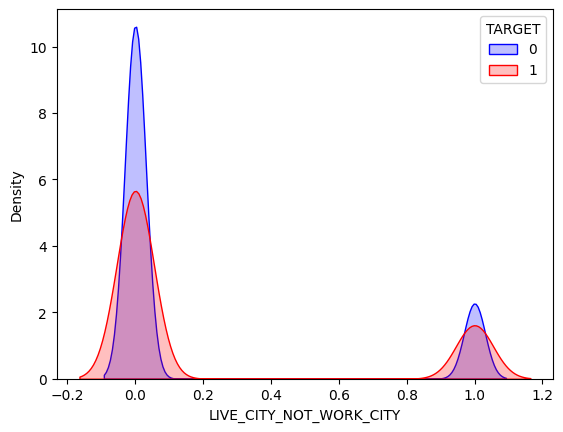

In [14]:
for col in [col for col in application_train.columns.values 
            if str(application_train[col].dtype).startswith('int') and not col.startswith('FLAG_') and col not in ['TARGET', "SK_ID_CURR"]]:
    print(f'Column: ', col)
    num_col_info(application_train, col)

#### Выводы

Прям каких то аномалий нет, кроме DAYS_EMPLOYED. Аномально большие значения больше нуля. Положительных значений априори быть не может, плюс оно аномально большое - очевидно ошибка в данных.
</br></br>
Еще в DAYS_BIRTH можно обратить внимание, что люди моложе чаще с дефолтиком.

### Глянем распределения флоат фич

Column:  AMT_INCOME_TOTAL


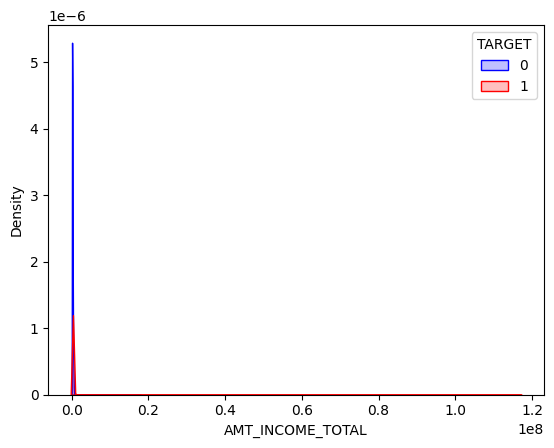

Column:  AMT_CREDIT


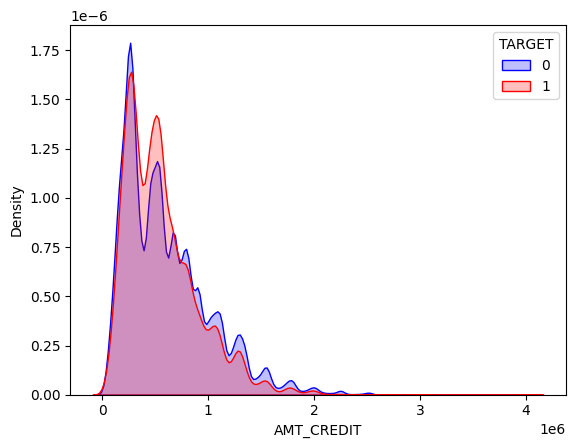

Column:  AMT_ANNUITY


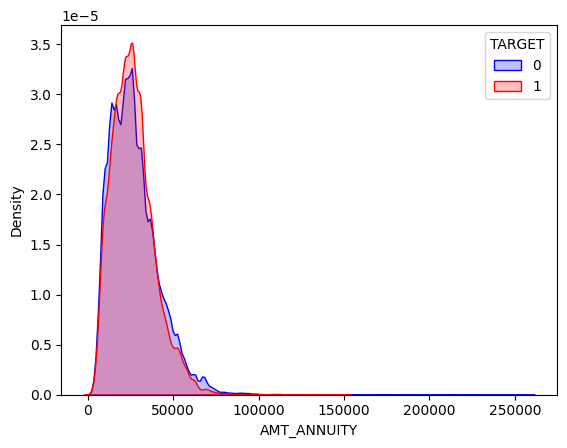

Column:  AMT_GOODS_PRICE


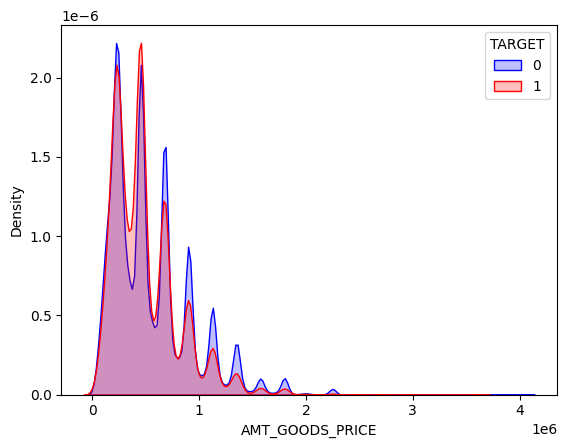

Column:  REGION_POPULATION_RELATIVE


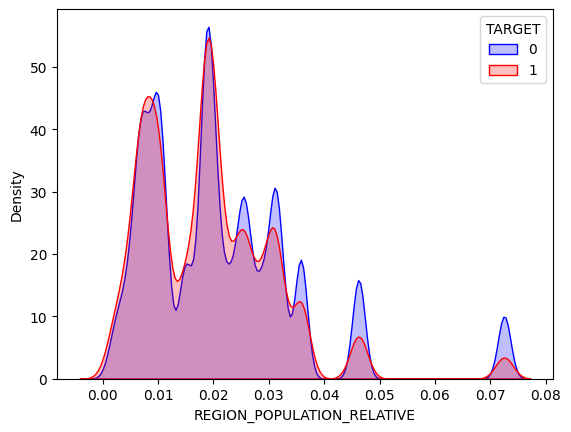

Column:  DAYS_REGISTRATION


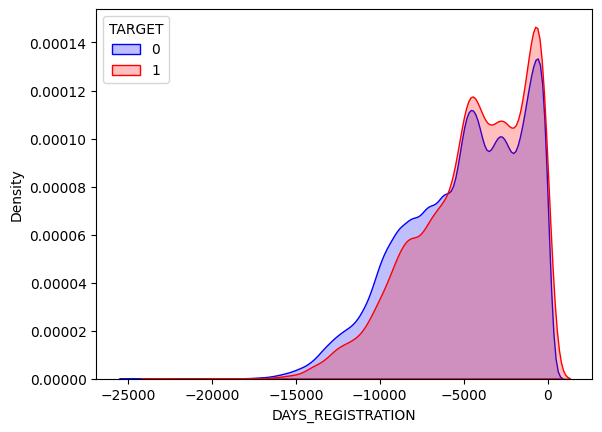

Column:  OWN_CAR_AGE


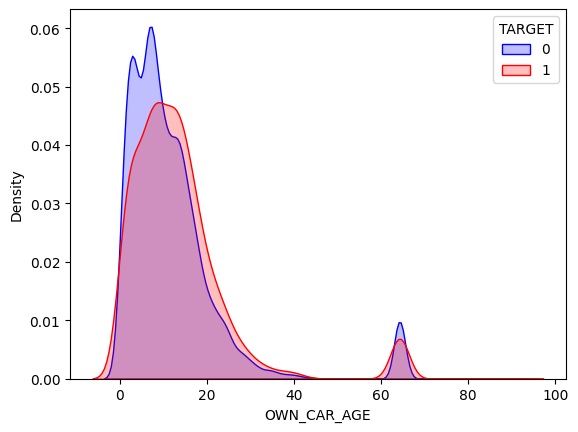

Column:  CNT_FAM_MEMBERS


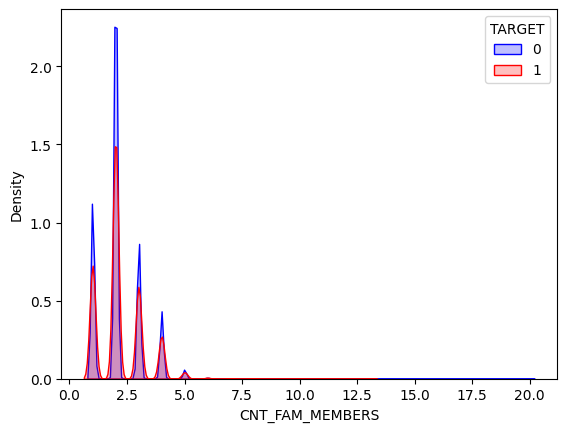

Column:  EXT_SOURCE_1


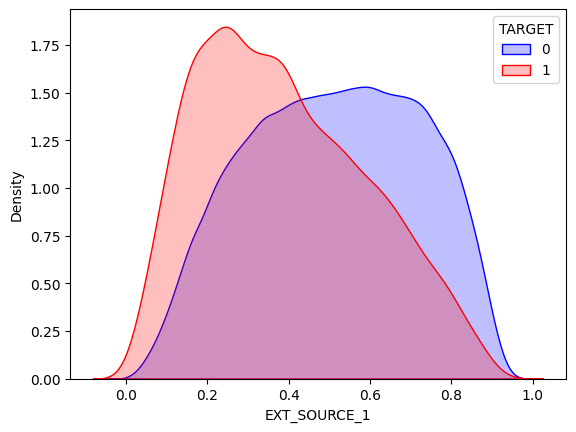

Column:  EXT_SOURCE_2


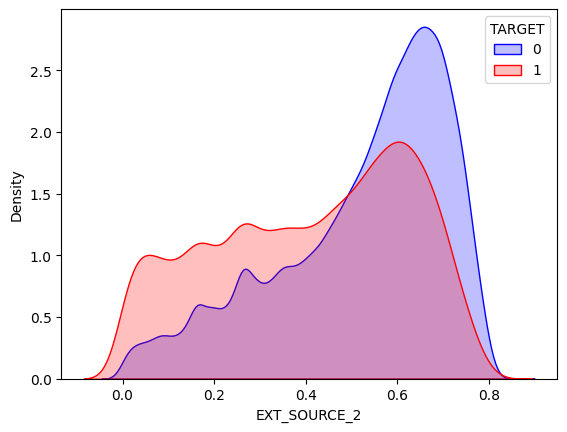

Column:  EXT_SOURCE_3


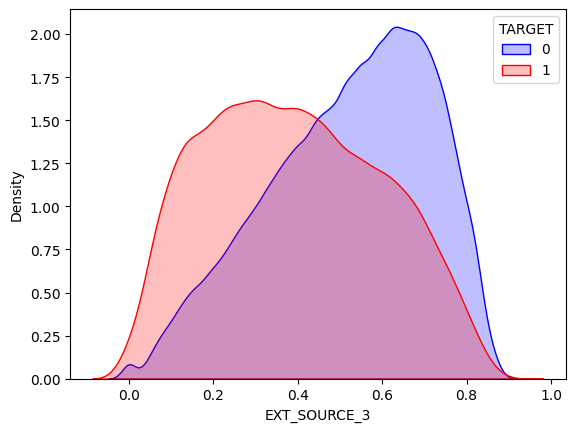

Column:  APARTMENTS_AVG


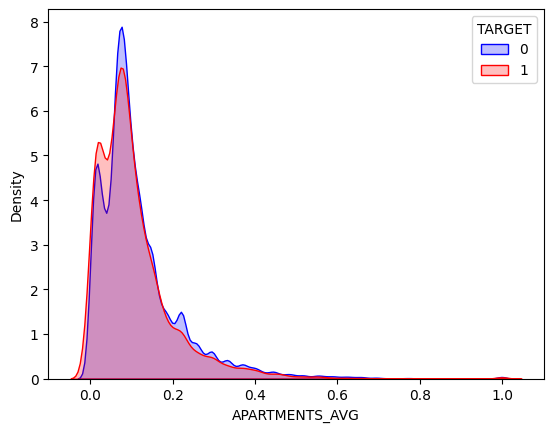

Column:  BASEMENTAREA_AVG


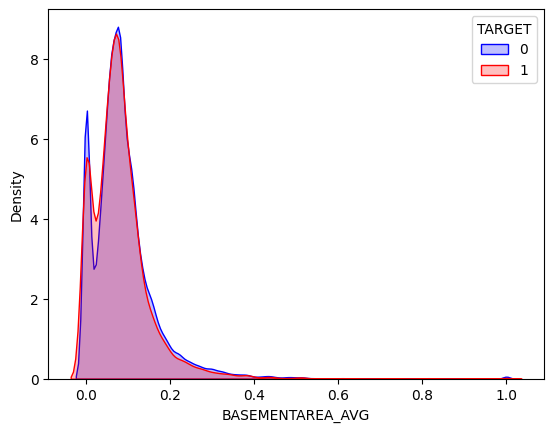

Column:  YEARS_BEGINEXPLUATATION_AVG


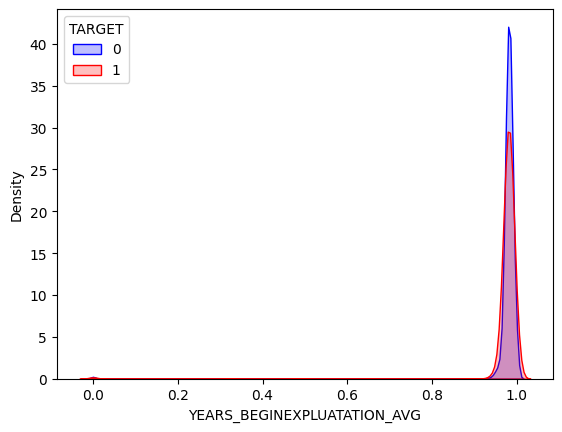

Column:  YEARS_BUILD_AVG


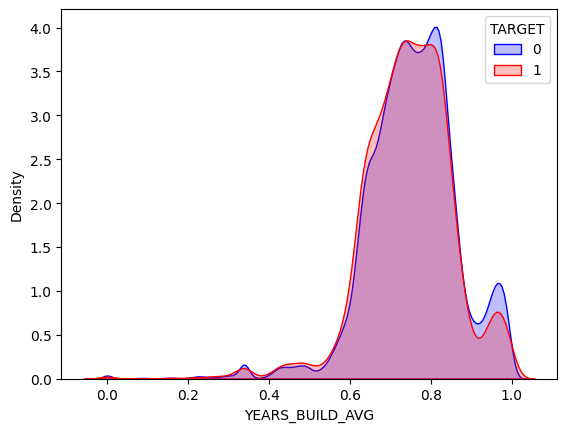

Column:  COMMONAREA_AVG


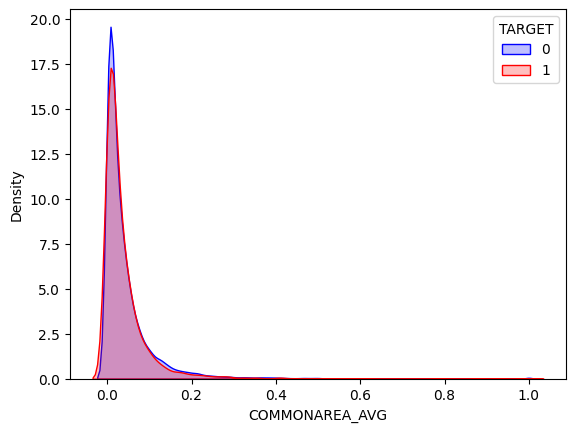

Column:  ELEVATORS_AVG


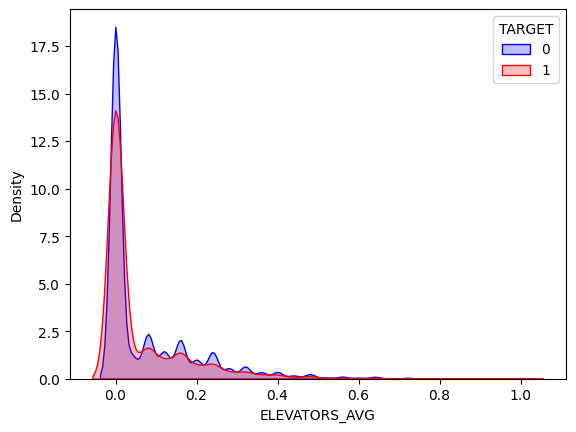

Column:  ENTRANCES_AVG


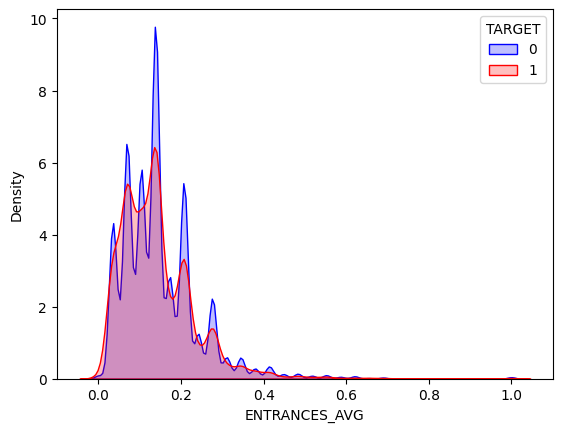

Column:  FLOORSMAX_AVG


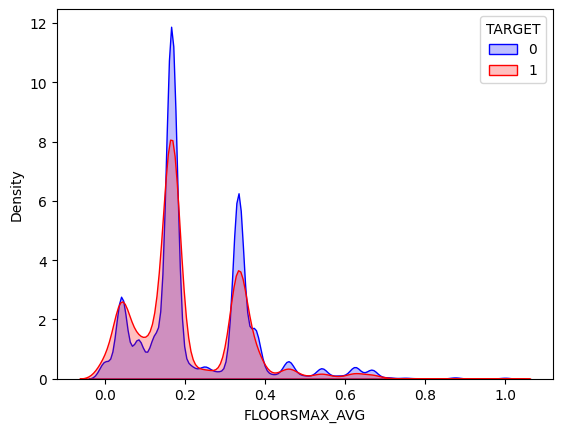

Column:  FLOORSMIN_AVG


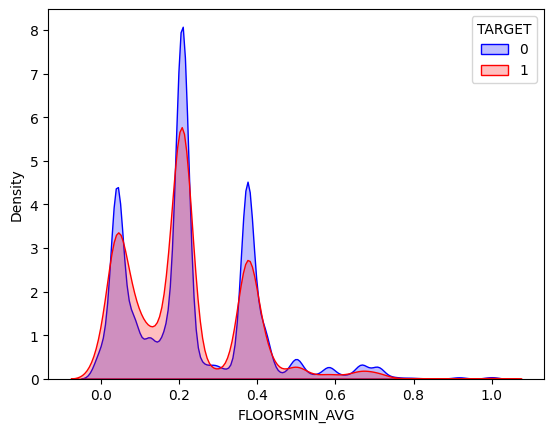

Column:  LANDAREA_AVG


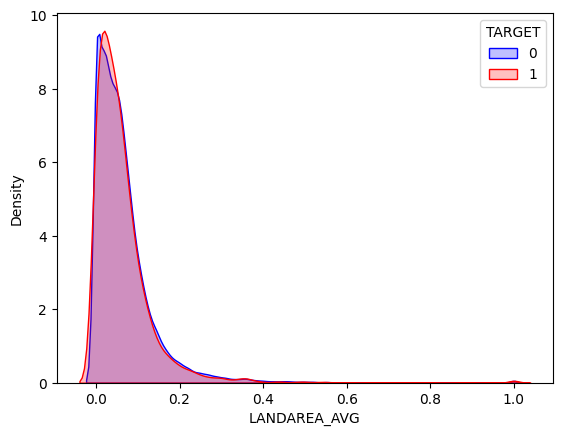

Column:  LIVINGAPARTMENTS_AVG


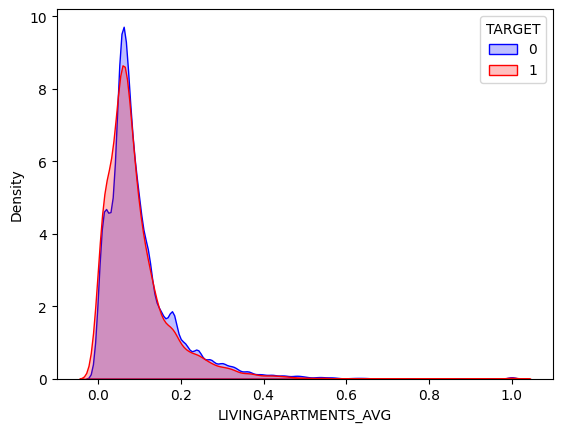

Column:  LIVINGAREA_AVG


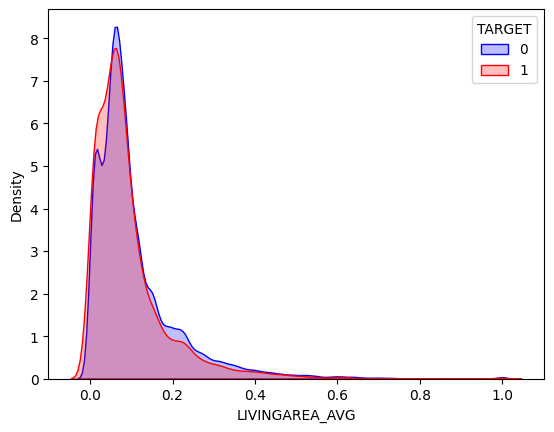

Column:  NONLIVINGAPARTMENTS_AVG


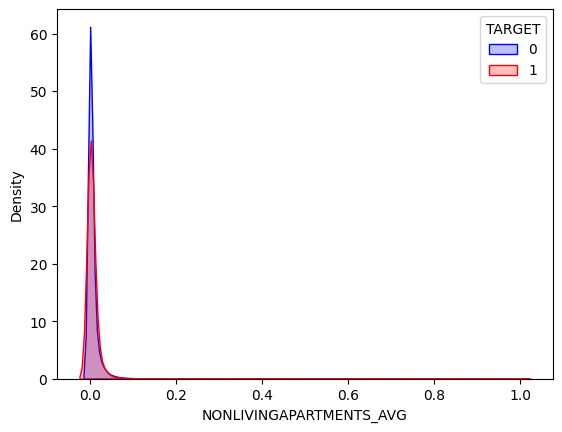

Column:  NONLIVINGAREA_AVG


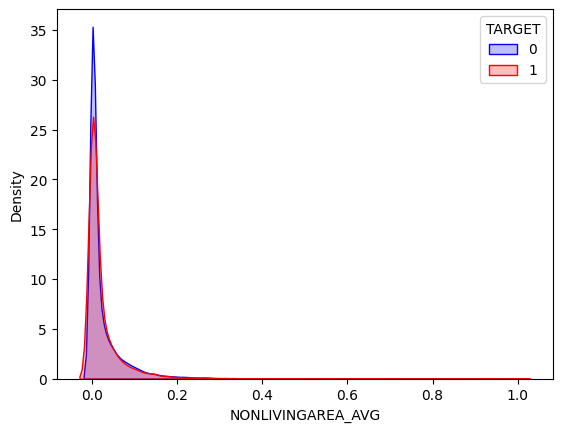

Column:  APARTMENTS_MODE


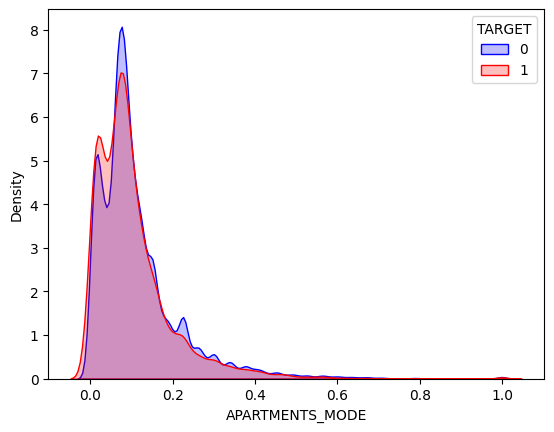

Column:  BASEMENTAREA_MODE


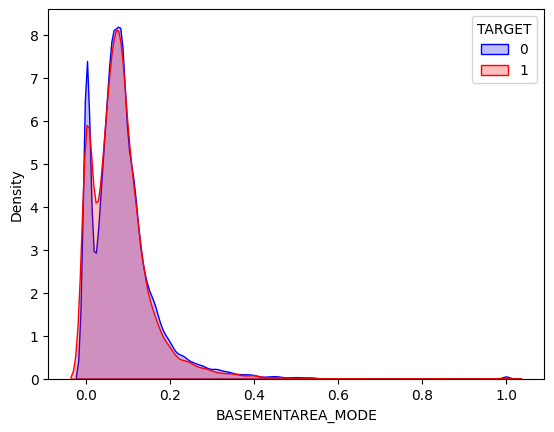

Column:  YEARS_BEGINEXPLUATATION_MODE


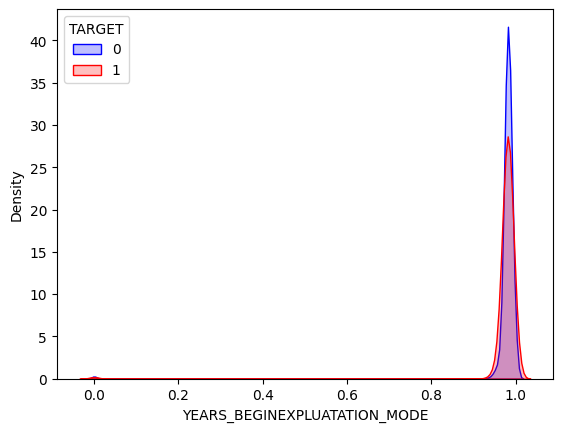

Column:  YEARS_BUILD_MODE


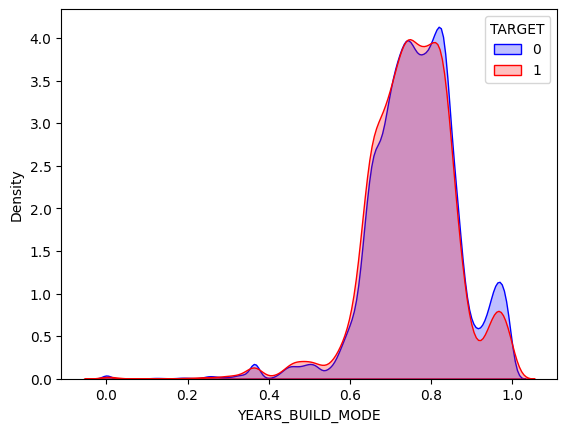

Column:  COMMONAREA_MODE


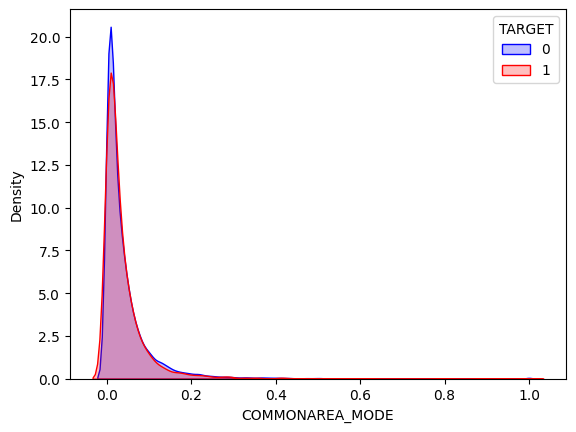

Column:  ELEVATORS_MODE


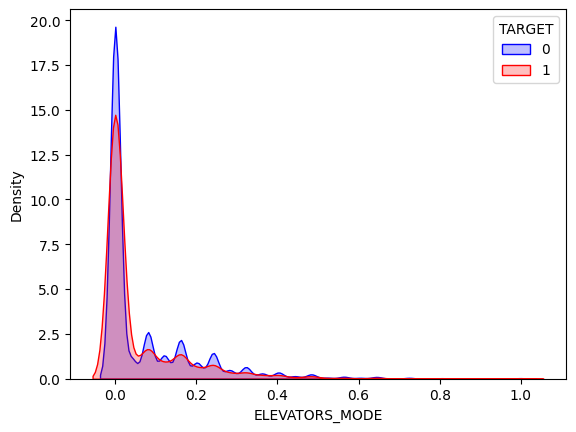

Column:  ENTRANCES_MODE


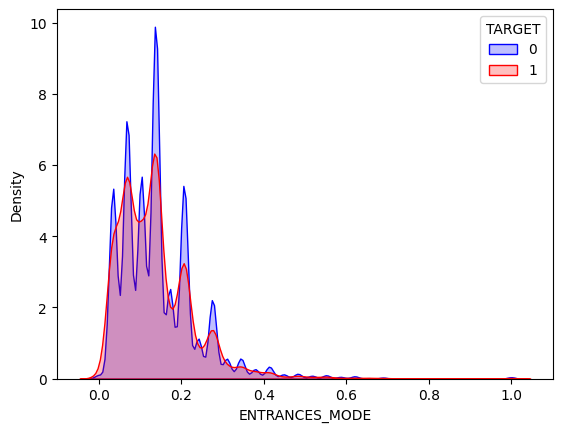

Column:  FLOORSMAX_MODE


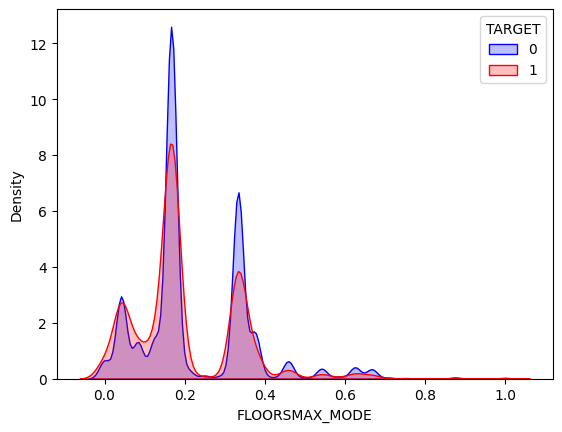

Column:  FLOORSMIN_MODE


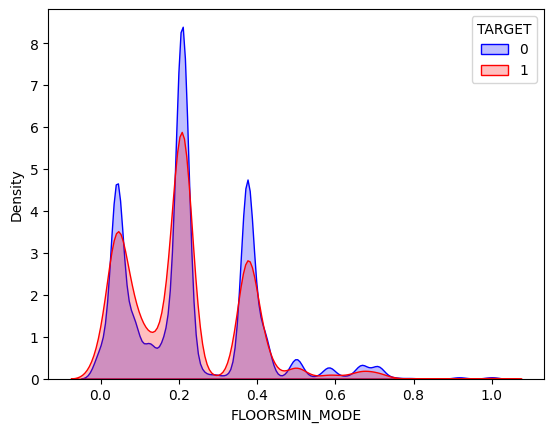

Column:  LANDAREA_MODE


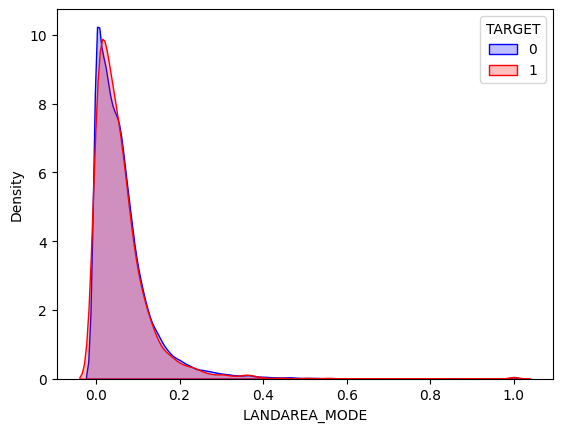

Column:  LIVINGAPARTMENTS_MODE


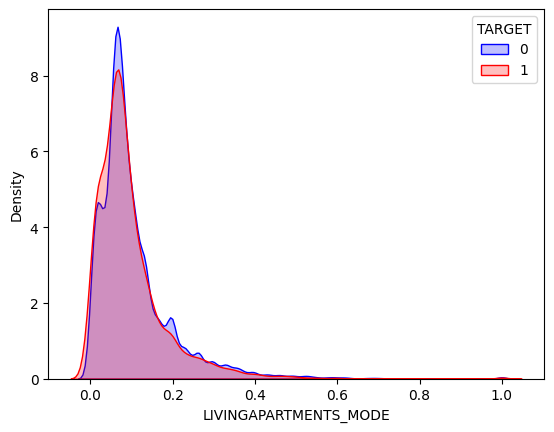

Column:  LIVINGAREA_MODE


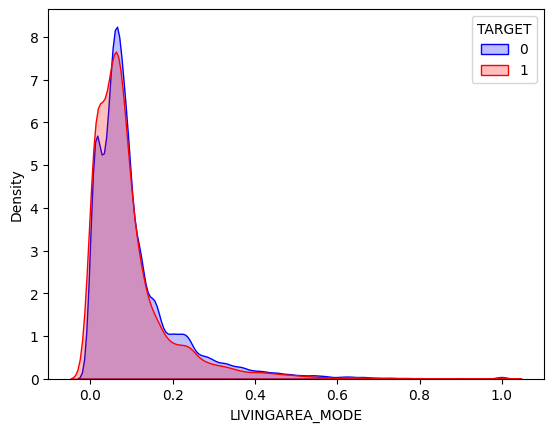

Column:  NONLIVINGAPARTMENTS_MODE


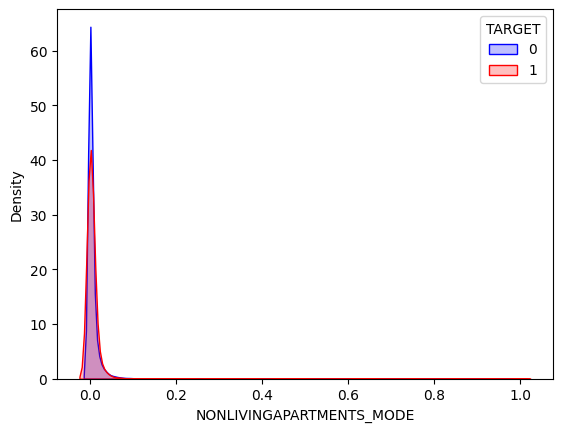

Column:  NONLIVINGAREA_MODE


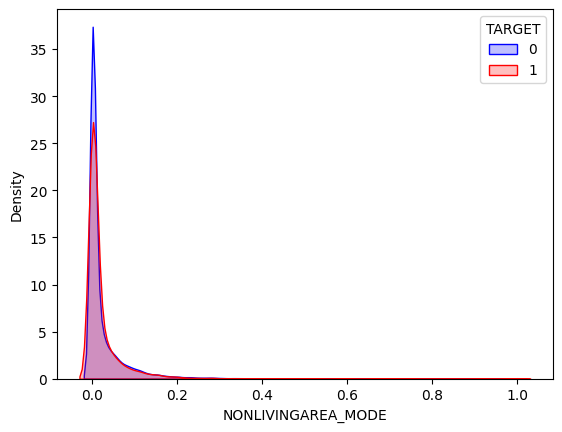

Column:  APARTMENTS_MEDI


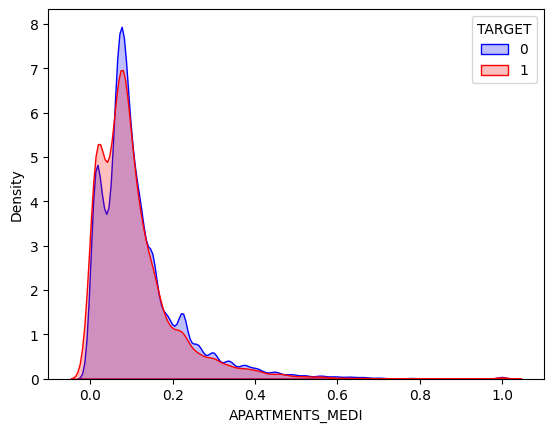

Column:  BASEMENTAREA_MEDI


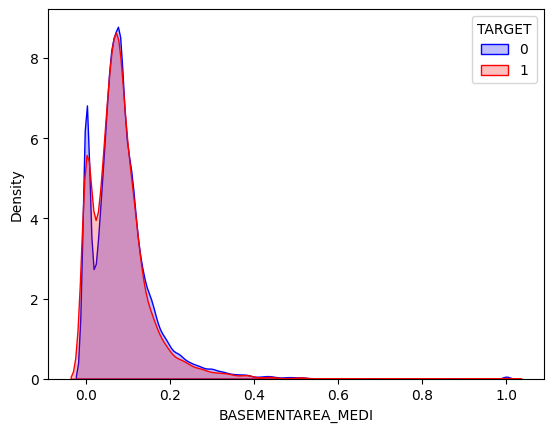

Column:  YEARS_BEGINEXPLUATATION_MEDI


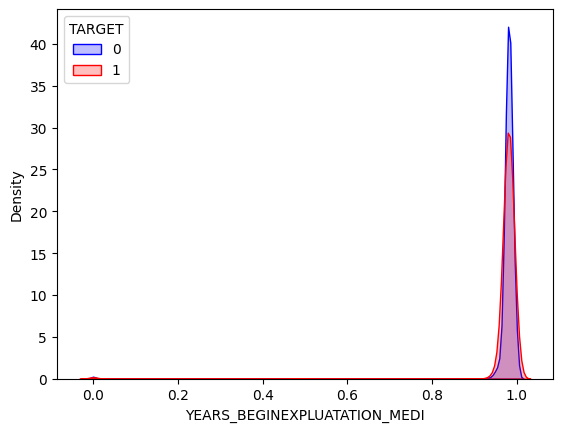

Column:  YEARS_BUILD_MEDI


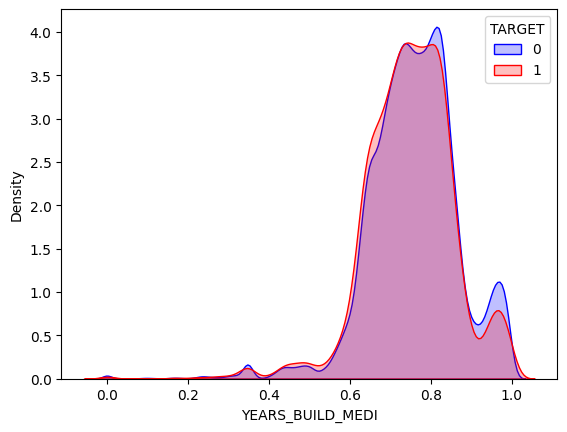

Column:  COMMONAREA_MEDI


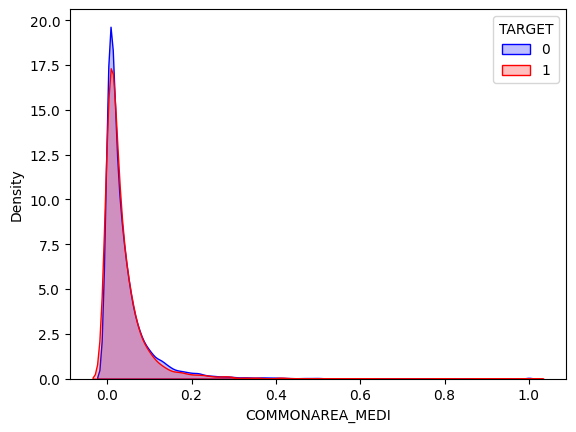

Column:  ELEVATORS_MEDI


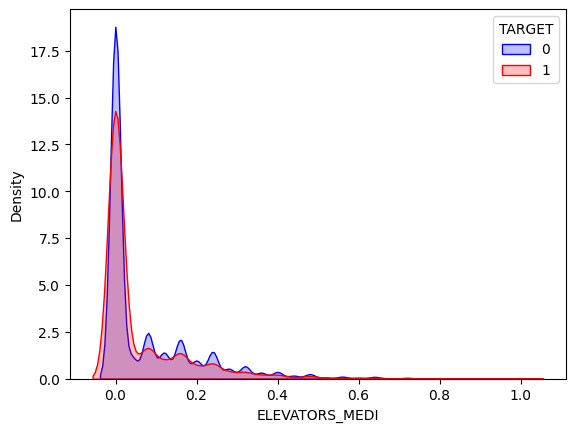

Column:  ENTRANCES_MEDI


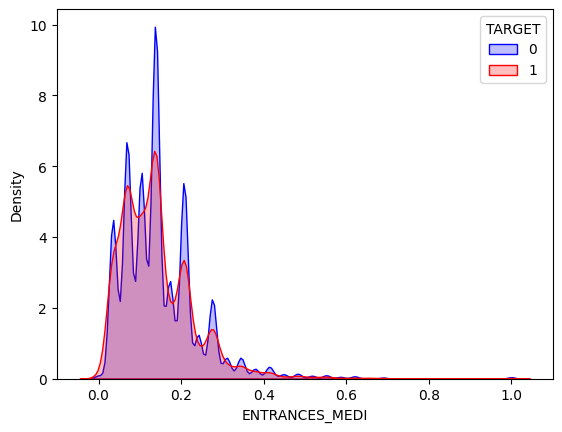

Column:  FLOORSMAX_MEDI


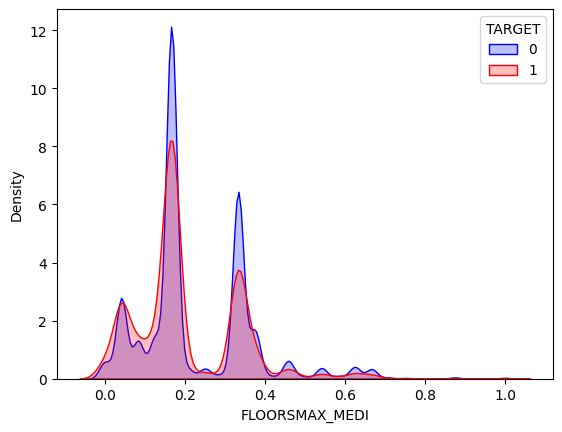

Column:  FLOORSMIN_MEDI


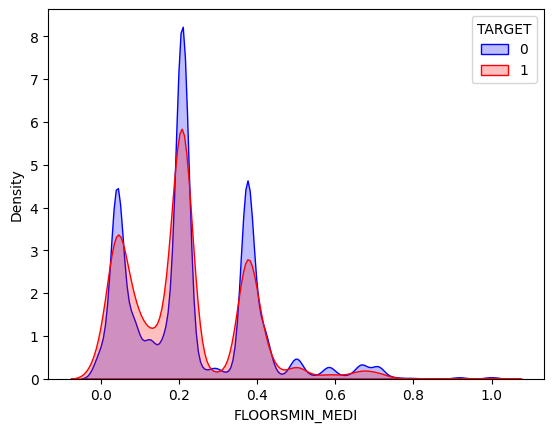

Column:  LANDAREA_MEDI


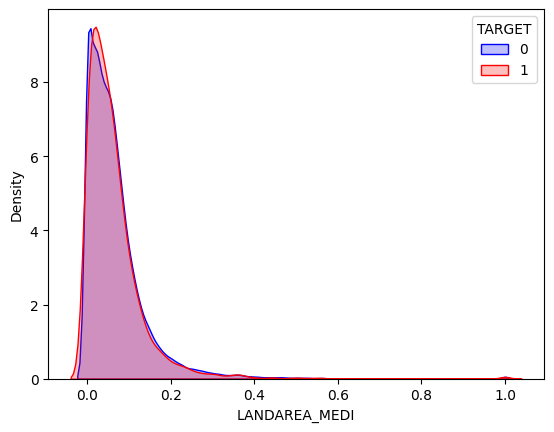

Column:  LIVINGAPARTMENTS_MEDI


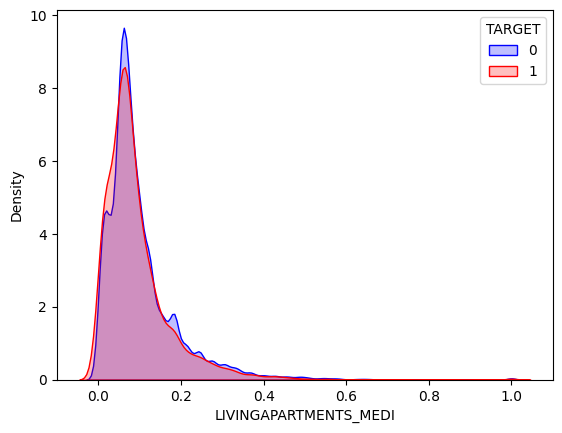

Column:  LIVINGAREA_MEDI


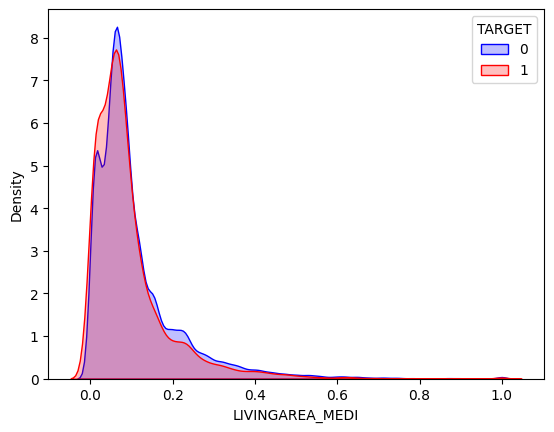

Column:  NONLIVINGAPARTMENTS_MEDI


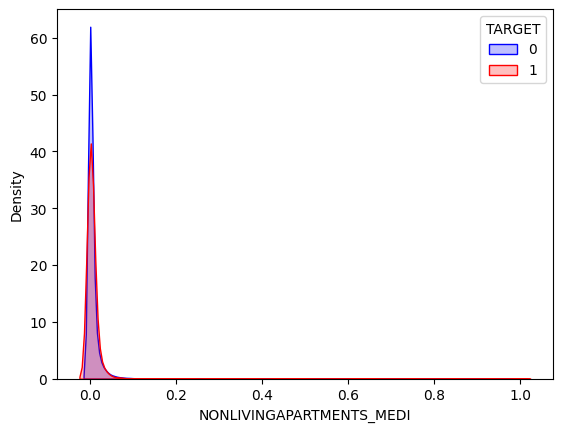

Column:  NONLIVINGAREA_MEDI


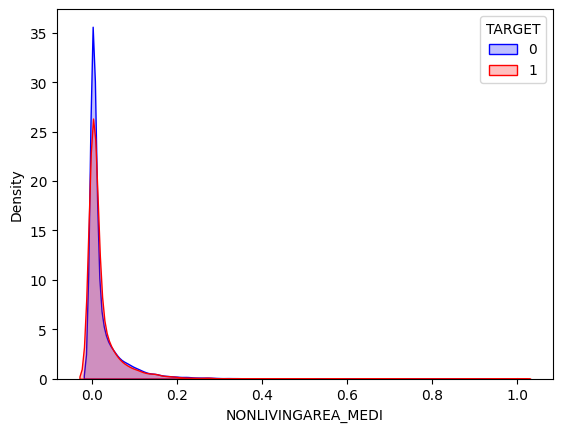

Column:  TOTALAREA_MODE


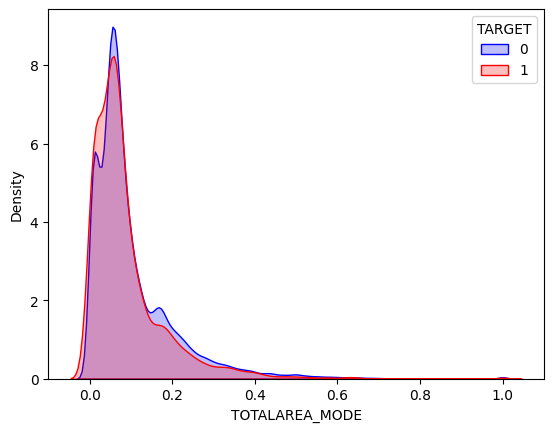

Column:  OBS_30_CNT_SOCIAL_CIRCLE


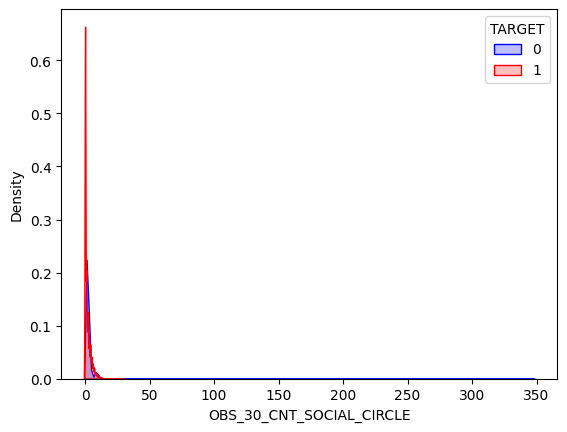

Column:  DEF_30_CNT_SOCIAL_CIRCLE


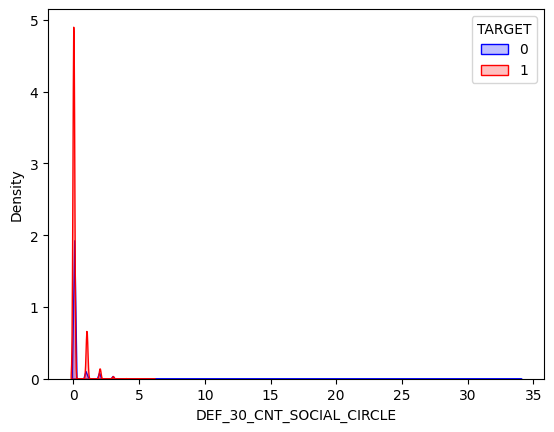

Column:  OBS_60_CNT_SOCIAL_CIRCLE


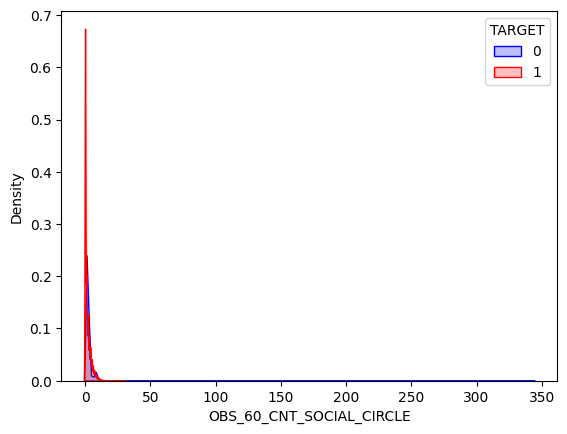

Column:  DEF_60_CNT_SOCIAL_CIRCLE


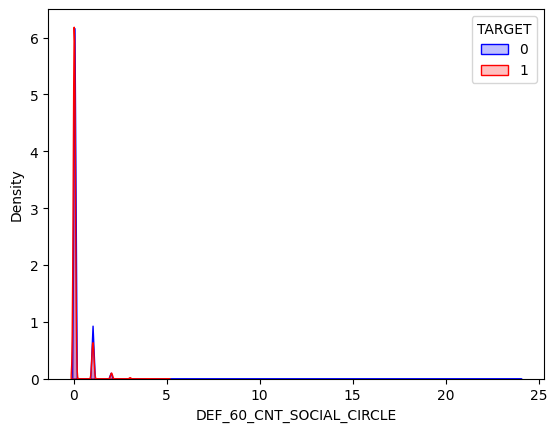

Column:  DAYS_LAST_PHONE_CHANGE


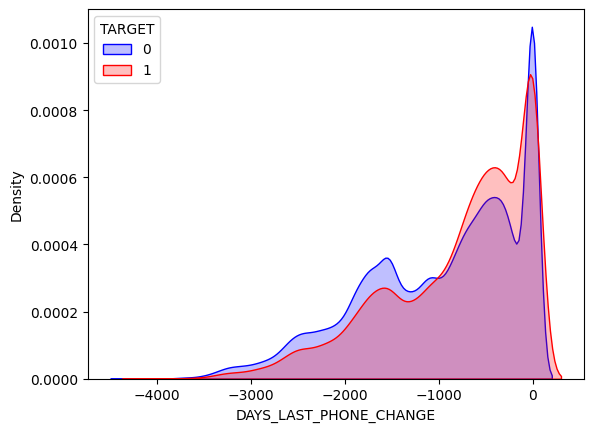

Column:  AMT_REQ_CREDIT_BUREAU_HOUR


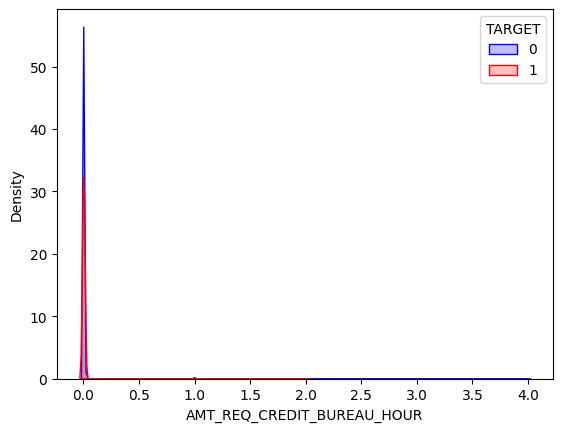

Column:  AMT_REQ_CREDIT_BUREAU_DAY


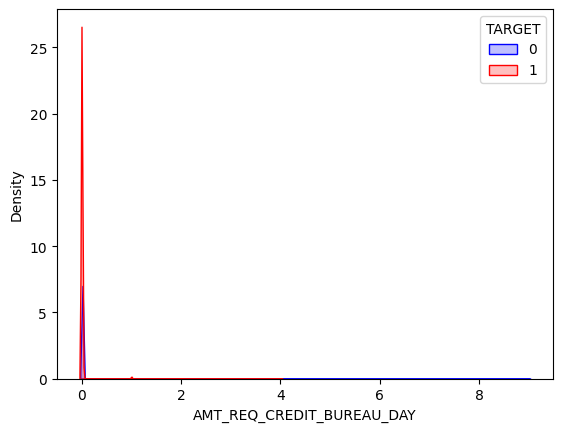

Column:  AMT_REQ_CREDIT_BUREAU_WEEK


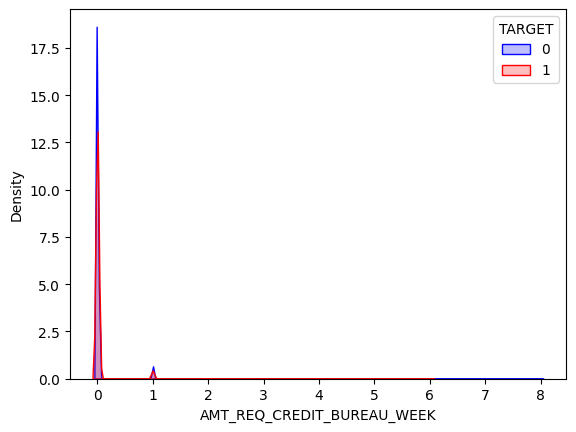

Column:  AMT_REQ_CREDIT_BUREAU_MON


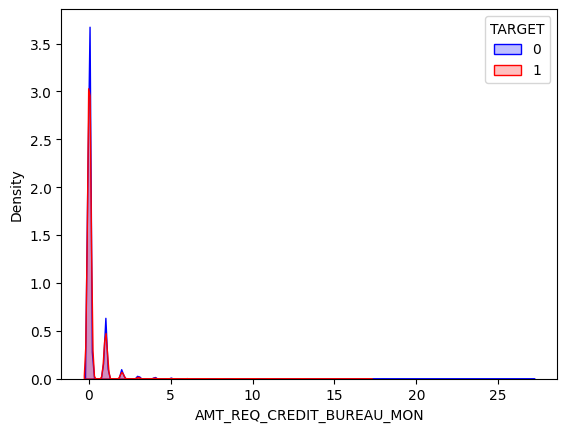

Column:  AMT_REQ_CREDIT_BUREAU_QRT


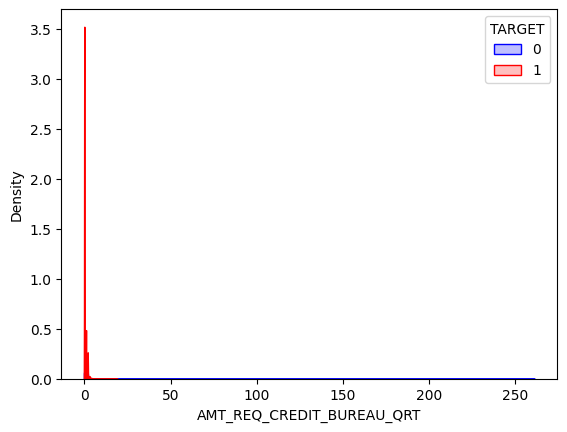

Column:  AMT_REQ_CREDIT_BUREAU_YEAR


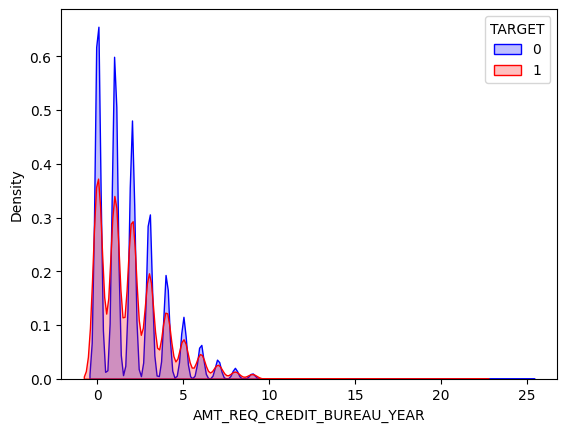

In [15]:
for col in [col for col in application_train.columns.values 
            if str(application_train[col].dtype).startswith('float')]:
    print(f'Column: ', col)
    num_col_info(application_train, col)

#### Что заметил
1. AMT_INCOME есть аномально большие значения. Либо выброс, либо оч богатый чел.
2. У EXT_SOURCES_ при разном таргете разное распределение. 
</br></br>
в остальном ничего интересного

### Посмотрим фичи наличия доков FLAG_DOCUMENT_*

In [33]:
flag_columns = [col for col in application_train.columns.values if col.startswith('FLAG_DOCUMENT')]

In [34]:
for col in flag_columns:
    display(pd.crosstab(application_train[col], application_train['TARGET']))

TARGET,0.0,1.0
FLAG_DOCUMENT_2,,
0.0,230293,21831
1.0,9,4


TARGET,0.0,1.0
FLAG_DOCUMENT_3,,
0.0,55857,3933
1.0,174445,17902


TARGET,0.0,1.0
FLAG_DOCUMENT_4,,
0.0,230282,21835
1.0,20,0


TARGET,0.0,1.0
FLAG_DOCUMENT_5,,
0.0,226553,21486
1.0,3749,349


TARGET,0.0,1.0
FLAG_DOCUMENT_6,,
0.0,228250,21701
1.0,2052,134


...

TARGET,0.0,1.0
FLAG_DOCUMENT_17,,
0.0,230223,21833
1.0,79,2


TARGET,0.0,1.0
FLAG_DOCUMENT_18,,
0.0,227964,21693
1.0,2338,142


TARGET,0.0,1.0
FLAG_DOCUMENT_19,,
0.0,230135,21823
1.0,167,12


TARGET,0.0,1.0
FLAG_DOCUMENT_20,,
0.0,230160,21822
1.0,142,13


TARGET,0.0,1.0
FLAG_DOCUMENT_21,,
0.0,230213,21821
1.0,89,14


#### Ну че то есть.
При наличии доков больше людей выплачивает кредит. Как будто важные фичи

### Глянем кредитные фичи: размер кредита, платеж и тд

<Axes: xlabel='AMT_CREDIT', ylabel='AMT_INCOME_TOTAL'>

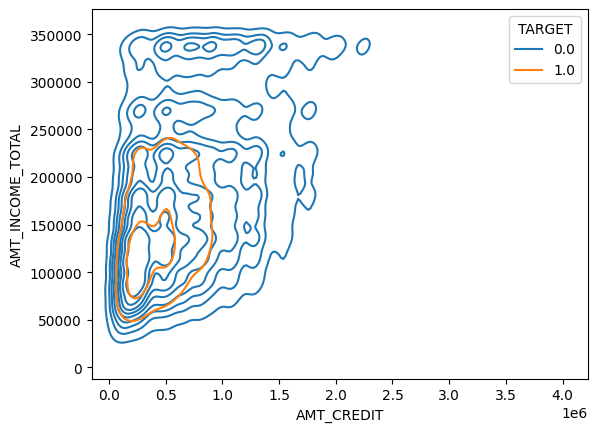

In [36]:
sns.kdeplot(application_train, x='AMT_CREDIT', y='AMT_INCOME_TOTAL', hue='TARGET')

<Axes: xlabel='AMT_CREDIT', ylabel='AMT_ANNUITY'>

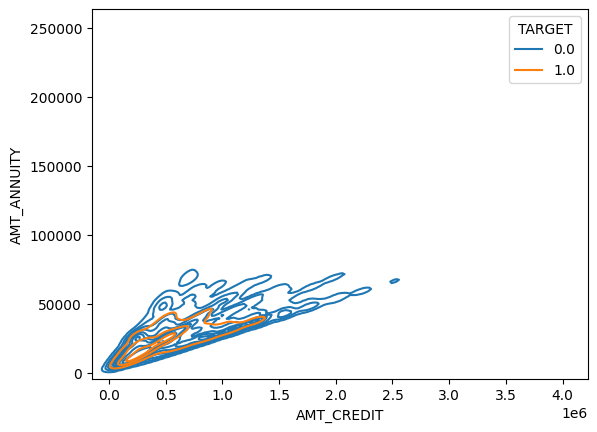

In [37]:
sns.kdeplot(application_train, x='AMT_CREDIT', y='AMT_ANNUITY', hue='TARGET')

<Axes: xlabel='AMT_CREDIT', ylabel='AMT_ANNUITY'>

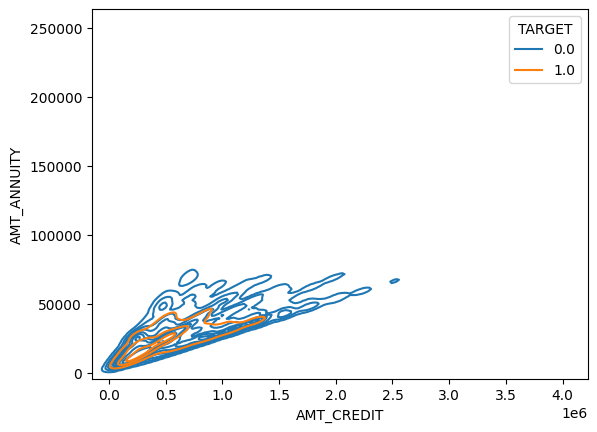

In [38]:
sns.kdeplot(application_train, x='AMT_CREDIT', y='AMT_ANNUITY', hue='TARGET')

<Axes: xlabel='AMT_CREDIT', ylabel='AMT_GOODS_PRICE'>

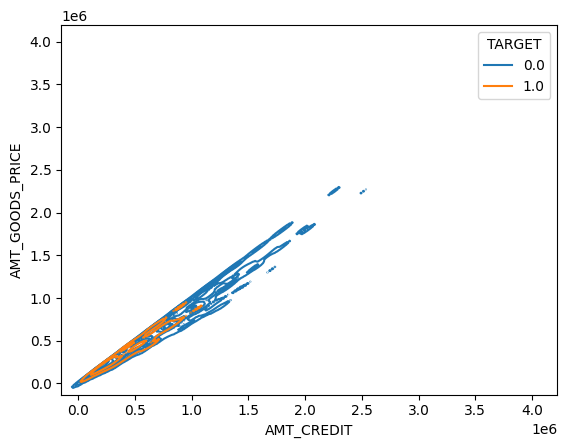

In [40]:
sns.kdeplot(application_train, x='AMT_CREDIT', y='AMT_GOODS_PRICE', hue='TARGET')

#### Че видно:
1. Между суммой кредита и другими фичами AMT_* видна линейная зависимость. С доходом не так выраженно, но на других четко видно.
2. Можно заметить что кредит выплачивается (TARGET = 0) во всем диапазоне - облака распределений большую площадь покрывает на всех графиках.
3. Кредит не вылпачивается (TARGET = 1) на высоких суммах кредита (>1-1.5млн). Облако распределения занимает меньшую площадь.
4. При низком доходе (до 150000) много дефолтов. При высоком доходе их значительно меньше.

### Расмотрим EXT_SOURCES

<Axes: xlabel='EXT_SOURCE_1', ylabel='EXT_SOURCE_2'>

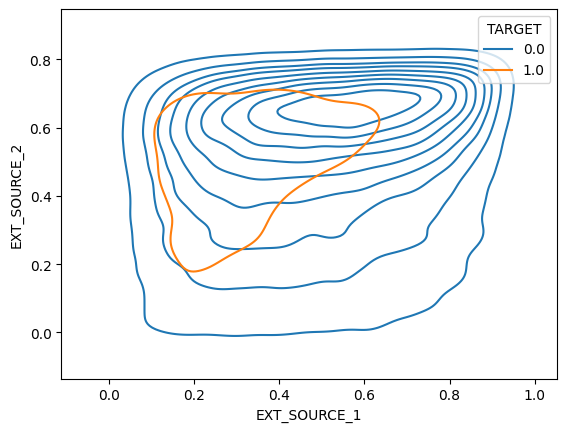

In [44]:
sns.kdeplot(application_train, x='EXT_SOURCE_1', y='EXT_SOURCE_2', hue='TARGET')

<Axes: xlabel='EXT_SOURCE_3', ylabel='EXT_SOURCE_2'>

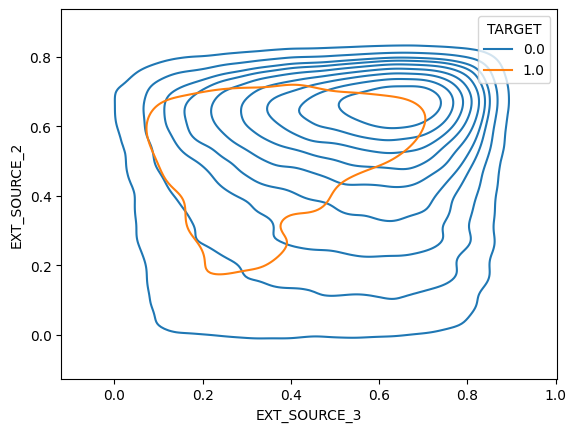

In [45]:
sns.kdeplot(application_train, x='EXT_SOURCE_3', y='EXT_SOURCE_2', hue='TARGET')

<Axes: xlabel='EXT_SOURCE_1', ylabel='EXT_SOURCE_3'>

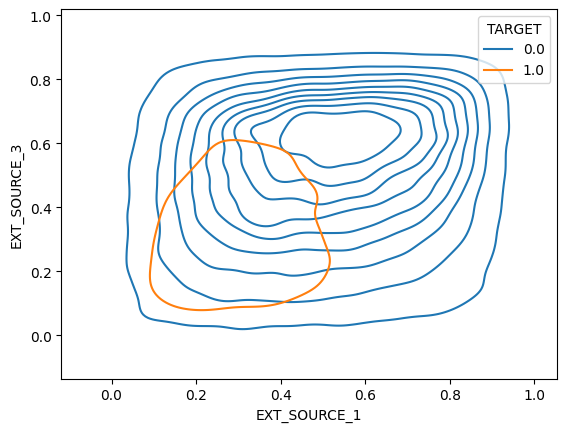

In [46]:
sns.kdeplot(application_train, x='EXT_SOURCE_1', y='EXT_SOURCE_3', hue='TARGET')

#### че то видно
1. При TARGET = 0, облака распределений по всему диапазону значений, центры распределений находятся при средне-высоких значениях (0.5-0.7).
5. Облака распределений при TARGET = 1 сжаты по диапозону значений, центры распределений находятся при признаках EXT_SOURCE_1, EXT_SOURCE_3 в значениях 0.2-0.4, при признаке EXT_SOURCE_2 - 0.4-0.6
2. Чем выше EXT_SOUCE_1 и ниже EXT_SOURCE_2, тем меньше дефолтов.
3. Чем выше EXT_SOUCE_3 и ниже EXT_SOURCE_2, тем меньше дефолтов.
4. Чем выше EXT_SOURCE_1 и EXT_SOURCE_3, тем меньше дефолтов.

### Категориальные признаки

In [71]:
def sort_key(x):
    try:
        return (0, float(x))
    except:
        return (1, str(x))

def cat_col_info(data: pd.DataFrame, col: str, target='TARGET'):
    pd.crosstab(application_train[col], application_train[target], normalize=True).plot(kind='bar', stacked=True)
    plt.grid(axis='y')
    plt.show()

Column:  NAME_CONTRACT_TYPE


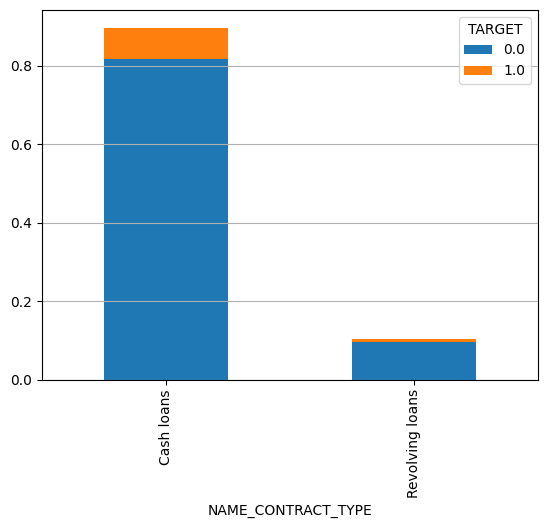

Column:  CODE_GENDER


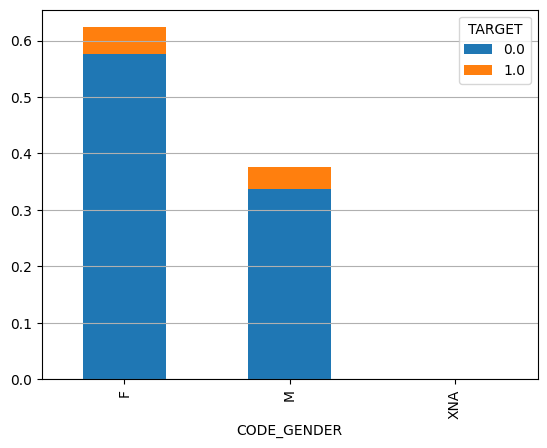

Column:  FLAG_OWN_CAR


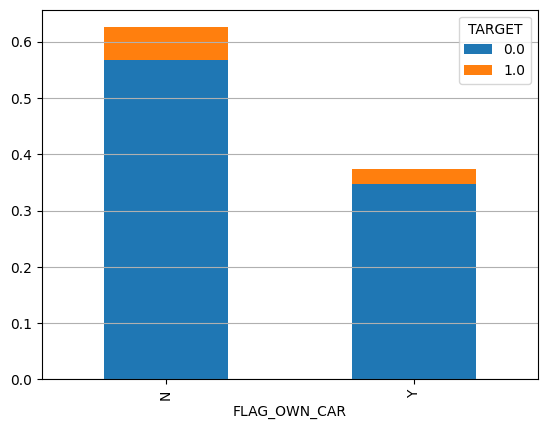

Column:  FLAG_OWN_REALTY


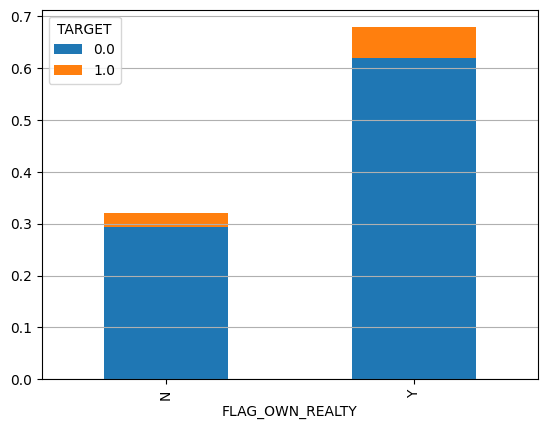

Column:  NAME_TYPE_SUITE


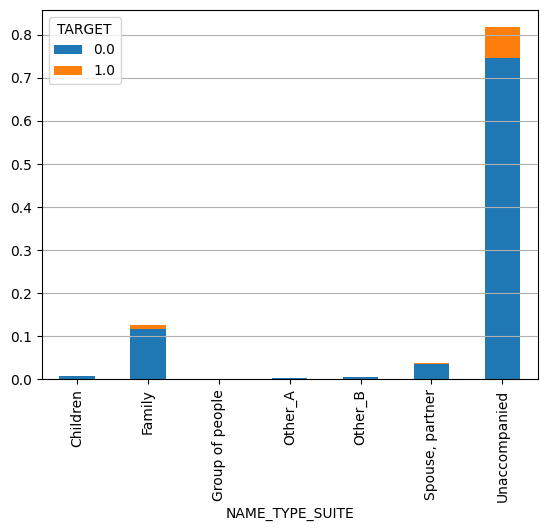

Column:  NAME_INCOME_TYPE


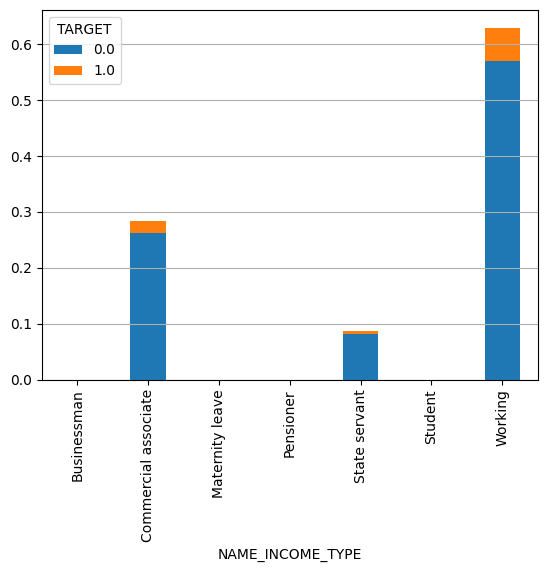

Column:  NAME_EDUCATION_TYPE


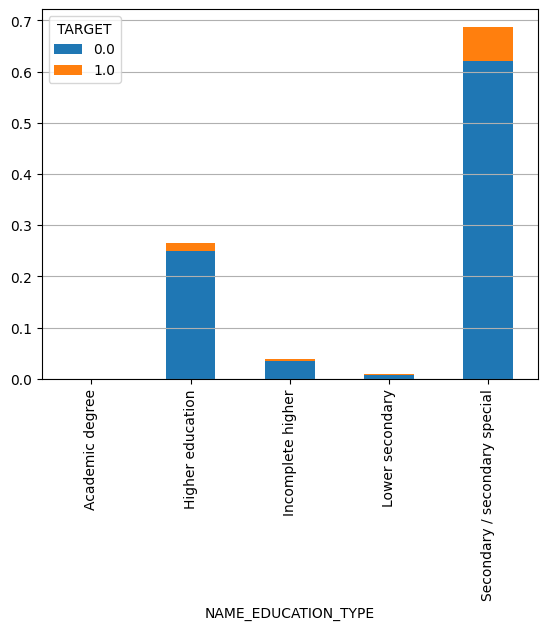

Column:  NAME_FAMILY_STATUS


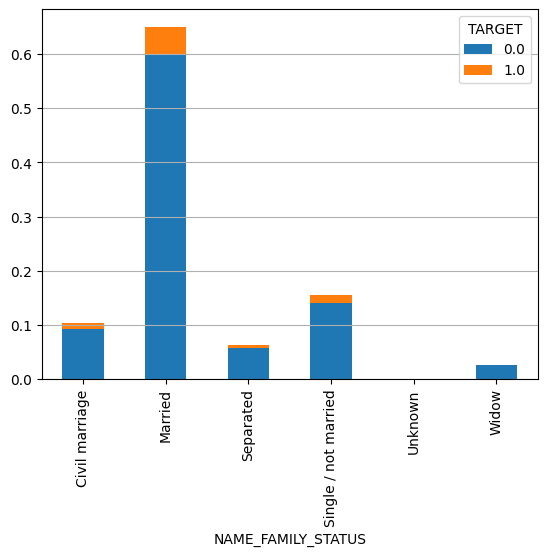

Column:  NAME_HOUSING_TYPE


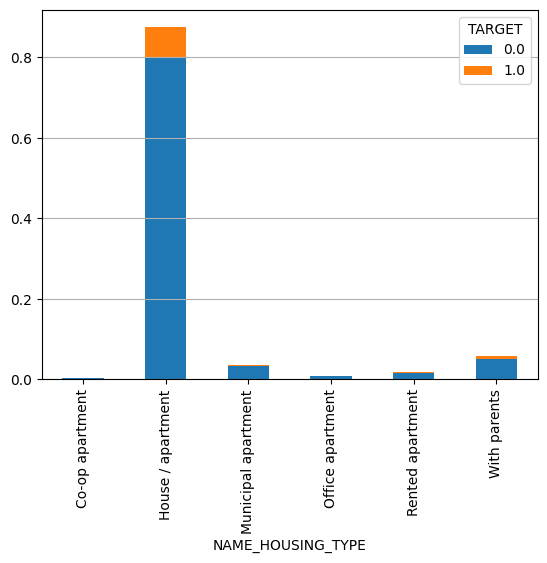

Column:  OCCUPATION_TYPE


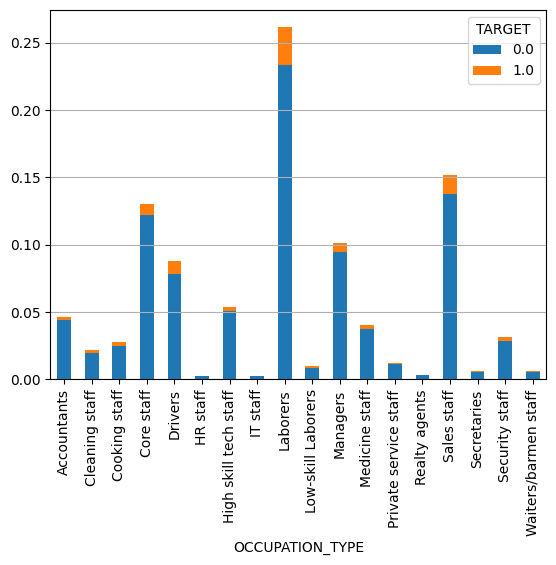

Column:  WEEKDAY_APPR_PROCESS_START


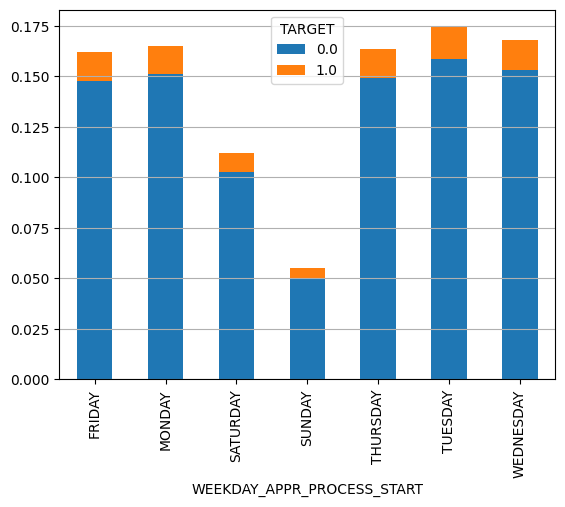

Column:  ORGANIZATION_TYPE


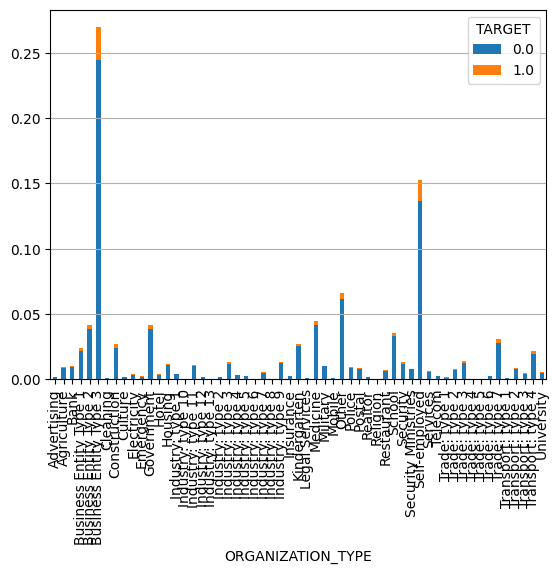

Column:  FONDKAPREMONT_MODE


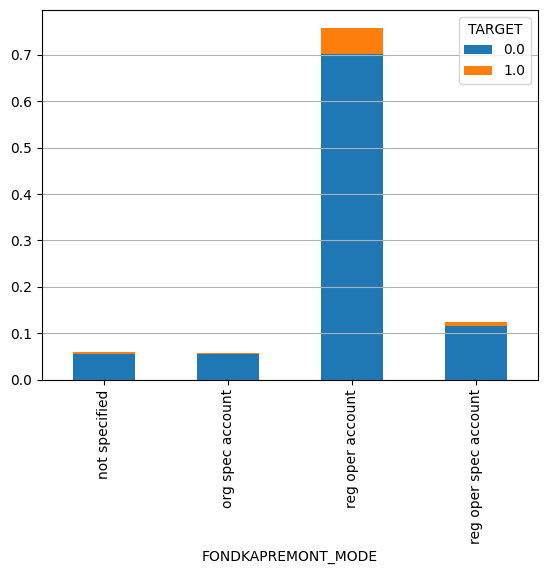

Column:  HOUSETYPE_MODE


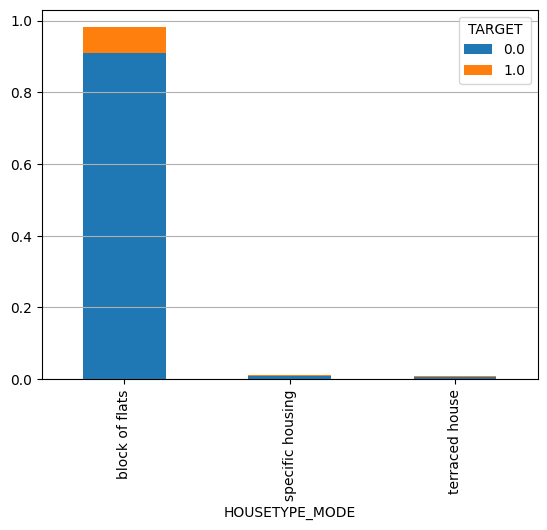

Column:  WALLSMATERIAL_MODE


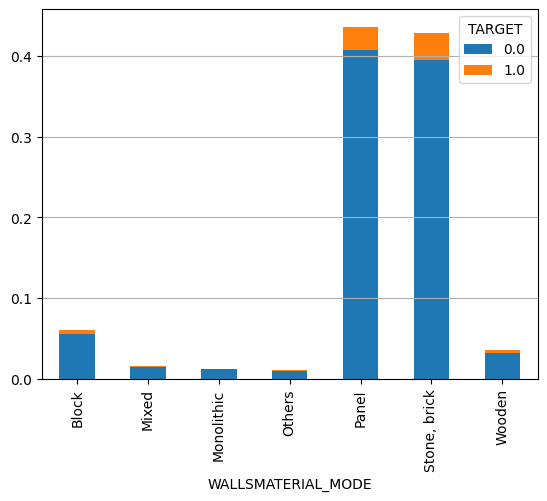

Column:  EMERGENCYSTATE_MODE


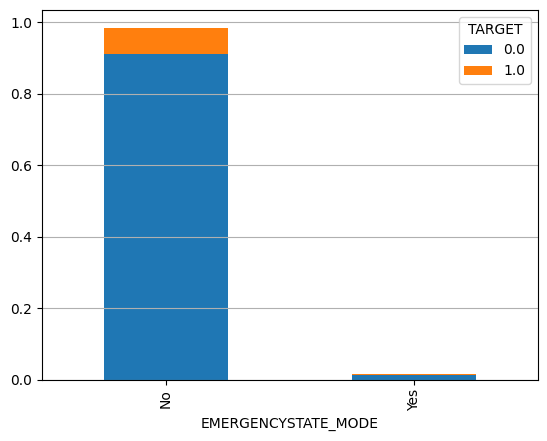

In [72]:
for cat_col in [col for col in application_train.columns.values if application_train[col].dtype == 'object']:
    print(f"Column: ", cat_col)
    cat_col_info(application_train, cat_col)
    print('='*50)

#### Выводы
1. У всех фичей дисбаланс классов. У некоторых вообще дикий, к примеру HOUSETYPE_MODE, EMERGENCYSTATE_MODE.
2. При этом соотношение таргетов в классах плюс минус одинаковое соотношение, нет классов где преобладал бы TARGET = 1.

## Bureau

In [18]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [19]:
bureau.info(True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


In [20]:
bureau.describe()

,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
count,1.716428e+06,1.716428e+06,1.716428e+06,1.716428e+06,1.610875e+06,1.082775e+06,5.919400e+05,1.716428e+06,1.716415e+06,1.458759e+06,1.124648e+06,1.716428e+06,1.716428e+06,4.896370e+05
mean,2.782149e+05,5.924434e+06,-1.142108e+03,8.181666e-01,5.105174e+02,-1.017437e+03,3.825418e+03,6.410406e-03,3.549946e+05,1.370851e+05,6.229515e+03,3.791276e+01,-5.937483e+02,1.571276e+04
std,1.029386e+05,5.322657e+05,7.951649e+02,3.654443e+01,4.994220e+03,7.140106e+02,2.060316e+05,9.622391e-02,1.149811e+06,6.774011e+05,4.503203e+04,5.937650e+03,7.207473e+02,3.258269e+05
min,1.000010e+05,5.000000e+06,-2.922000e+03,0.000000e+00,-4.206000e+04,-4.202300e+04,0.000000e+00,0.000000e+00,0.000000e+00,-4.705600e+06,-5.864061e+05,0.000000e+00,-4.194700e+04,0.000000e+00
25%,1.888668e+05,5.463954e+06,-1.666000e+03,0.000000e+00,-1.138000e+03,-1.489000e+03,0.000000e+00,0.000000e+00,5.130000e+04,0.000000e+00,0.000000e+00,0.000000e+00,-9.080000e+02,0.000000e+00
50%,2.780550e+05,5.926304e+06,-9.870000e+02,0.000000e+00,-3.300000e+02,-8.970000e+02,0.000000e+00,0.000000e+00,1.255185e+05,0.000000e+00,0.000000e+00,0.000000e+00,-3.950000e+02,0.000000e+00
75%,3.674260e+05,6.385681e+06,-4.740000e+02,0.000000e+00,4.740000e+02,-4.250000e+02,0.000000e+00,0.000000e+00,3.150000e+05,4.015350e+04,0.000000e+00,0.000000e+00,-3.300000e+01,1.350000e+04
max,4.562550e+05,6.843457e+06,0.000000e+00,2.792000e+03,3.119900e+04,0.000000e+00,1.159872e+08,9.000000e+00,5.850000e+08,1.701000e+08,4.705600e+06,3.756681e+06,3.720000e+02,1.184534e+08


In [21]:
bureau['CREDIT_ACTIVE'].unique()

array(['Closed', 'Active', 'Sold', 'Bad debt'], dtype=object)

<Axes: xlabel='count', ylabel='CREDIT_TYPE'>

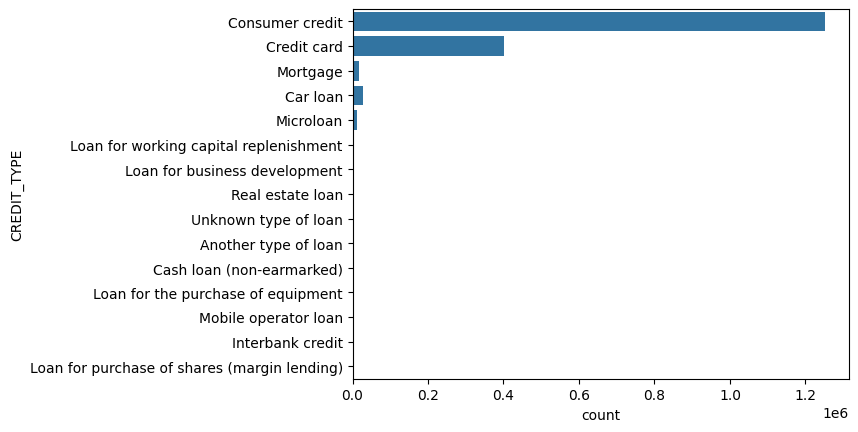

In [60]:
sns.countplot(data=bureau, y='CREDIT_TYPE')

<Axes: xlabel='CREDIT_TYPE'>

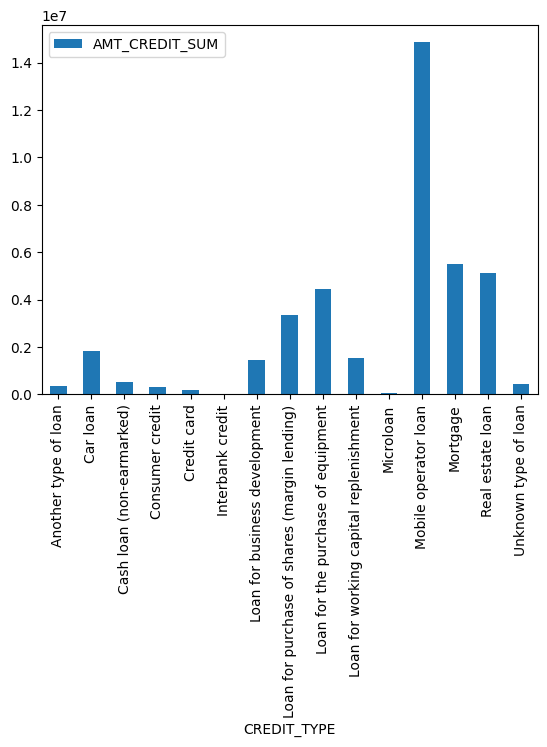

In [23]:
bureau.groupby('CREDIT_TYPE')[['AMT_CREDIT_SUM']].mean().plot(kind='bar')

## Bureau balance

In [29]:
bureau_balance.describe()

,SK_ID_BUREAU,MONTHS_BALANCE
count,2.729992e+07,2.729992e+07
mean,6.036297e+06,-3.074169e+01
std,4.923489e+05,2.386451e+01
min,5.001709e+06,-9.600000e+01
25%,5.730933e+06,-4.600000e+01
50%,6.070821e+06,-2.500000e+01
75%,6.431951e+06,-1.100000e+01
max,6.842888e+06,0.000000e+00


In [30]:
bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


<Axes: xlabel='percent', ylabel='STATUS'>

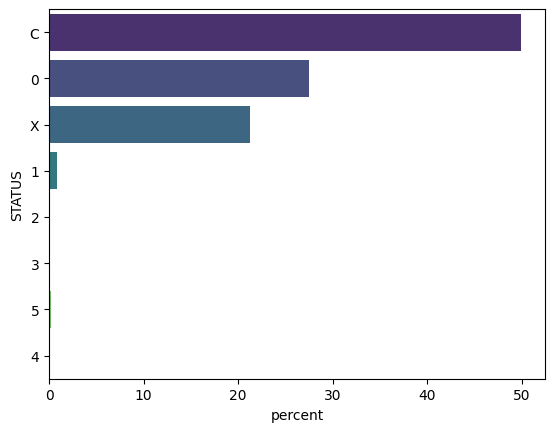

In [76]:
sns.countplot(bureau_balance, y='STATUS', palette='viridis', stat='percent')

## Credit card balance

In [ ]:
credit_card_balance.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,1800.0,1800.0,0.000,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,2250.0,2250.0,60175.080,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,2250.0,2250.0,26926.425,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,11925.0,11925.0,224949.285,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,27000.0,27000.0,443044.395,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [ ]:
credit_card_balance.describe()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,SK_DPD,SK_DPD_DEF
count,3.840312e+06,3.840312e+06,3.840312e+06,3.840312e+06,3.840312e+06,3.090496e+06,3.840312e+06,3.090496e+06,3.090496e+06,3.535076e+06,3.072324e+06,3.840312e+06,3.840312e+06,3.840312e+06,3.840312e+06,3.090496e+06,3.840312e+06,3.090496e+06,3.090496e+06,3.535076e+06,3.840312e+06,3.840312e+06
mean,1.904504e+06,2.783242e+05,-3.452192e+01,5.830016e+04,1.538080e+05,5.961325e+03,7.433388e+03,2.881696e+02,2.968805e+03,3.540204e+03,1.028054e+04,7.588857e+03,5.596588e+04,5.808881e+04,5.809829e+04,3.094490e-01,7.031439e-01,4.812496e-03,5.594791e-01,2.082508e+01,9.283667e+00,3.316220e-01
std,5.364695e+05,1.027045e+05,2.666775e+01,1.063070e+05,1.651457e+05,2.822569e+04,3.384608e+04,8.201989e+03,2.079689e+04,5.600154e+03,3.607808e+04,3.200599e+04,1.025336e+05,1.059654e+05,1.059718e+05,1.100401e+00,3.190347e+00,8.263861e-02,3.240649e+00,2.005149e+01,9.751570e+01,2.147923e+01
min,1.000018e+06,1.000060e+05,-9.600000e+01,-4.202502e+05,0.000000e+00,-6.827310e+03,-6.211620e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-4.233058e+05,-4.202502e+05,-4.202502e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.434385e+06,1.895170e+05,-5.500000e+01,0.000000e+00,4.500000e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.523700e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00
50%,1.897122e+06,2.783960e+05,-2.800000e+01,0.000000e+00,1.125000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.702700e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.500000e+01,0.000000e+00,0.000000e+00
75%,2.369328e+06,3.675800e+05,-1.100000e+01,8.904669e+04,1.800000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.633911e+03,9.000000e+03,6.750000e+03,8.535924e+04,8.889949e+04,8.891451e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00
max,2.843496e+06,4.562500e+05,-1.000000e+00,1.505902e+06,1.350000e+06,2.115000e+06,2.287098e+06,1.529847e+06,2.239274e+06,2.028820e+05,4.289207e+06,4.278316e+06,1.472317e+06,1.493338e+06,1.493338e+06,5.100000e+01,1.650000e+02,1.200000e+01,1.650000e+02,1.200000e+02,3.260000e+03,3.260000e+03


Column: AMT_BALANCE


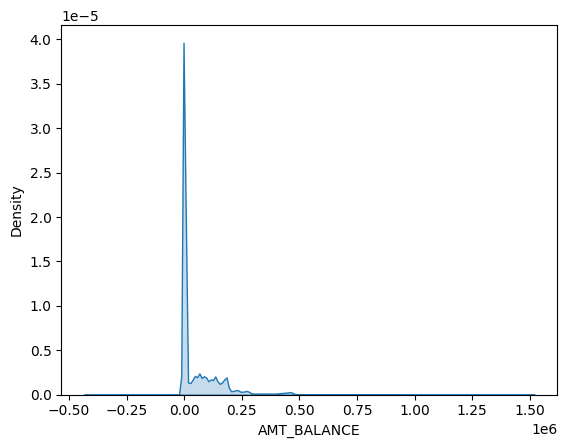

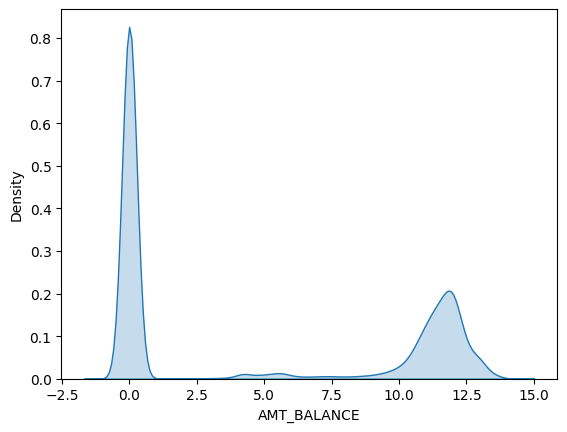

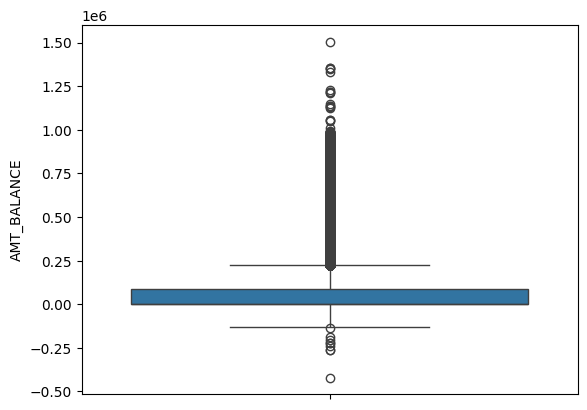

Column: AMT_DRAWINGS_ATM_CURRENT


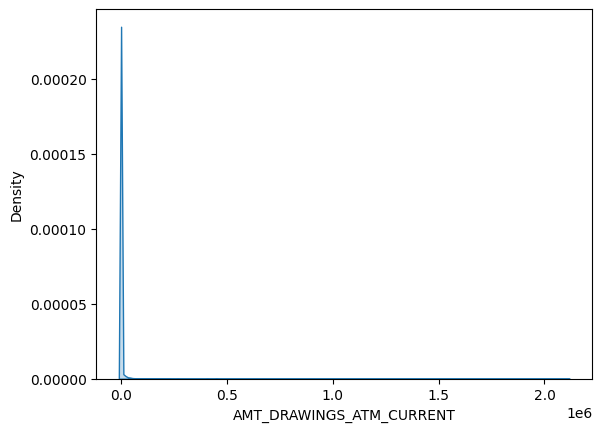

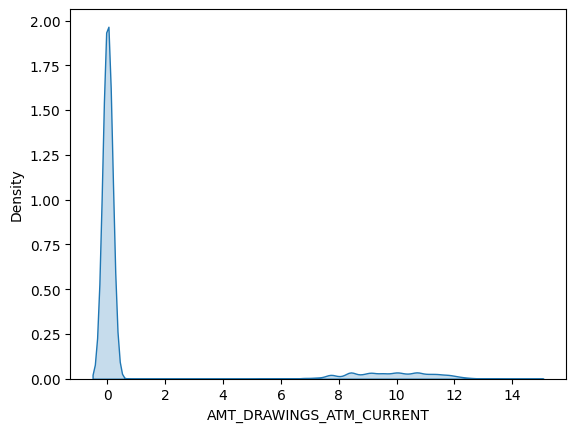

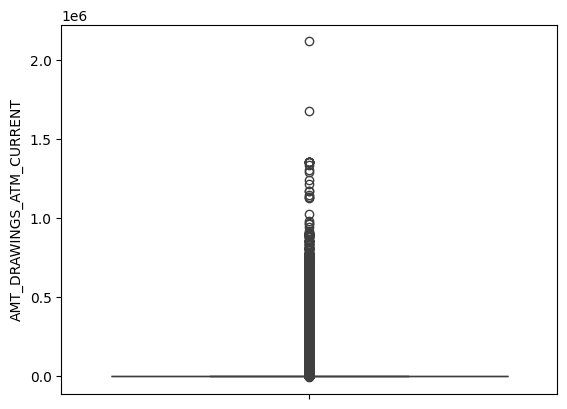

Column: AMT_DRAWINGS_CURRENT


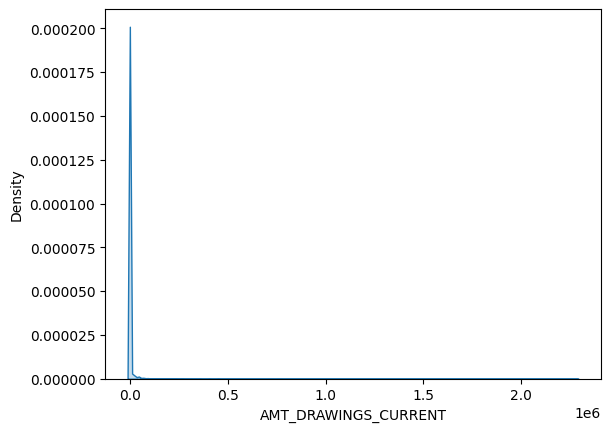

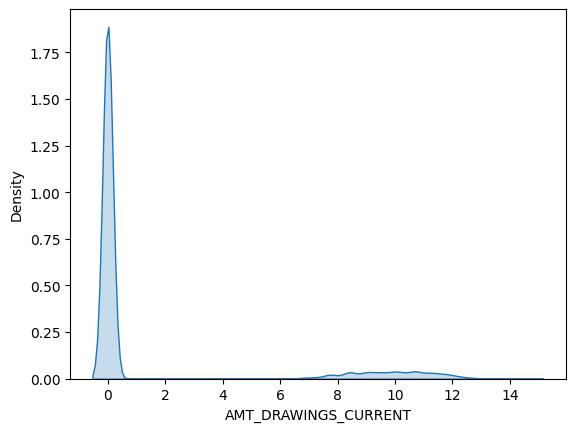

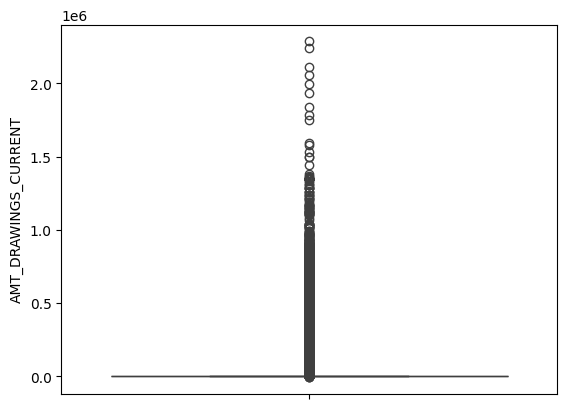

Column: AMT_DRAWINGS_OTHER_CURRENT


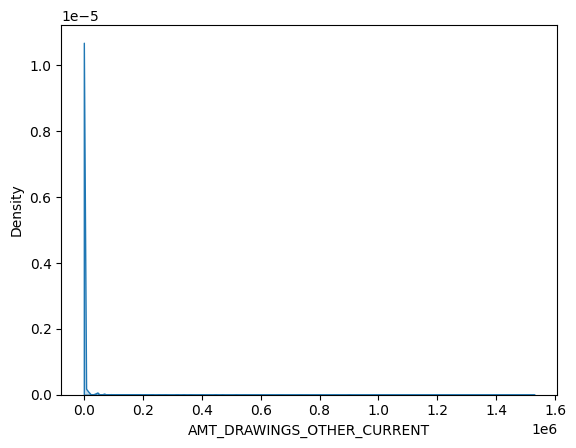

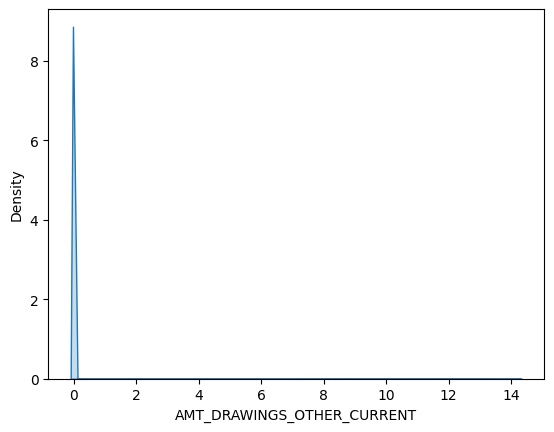

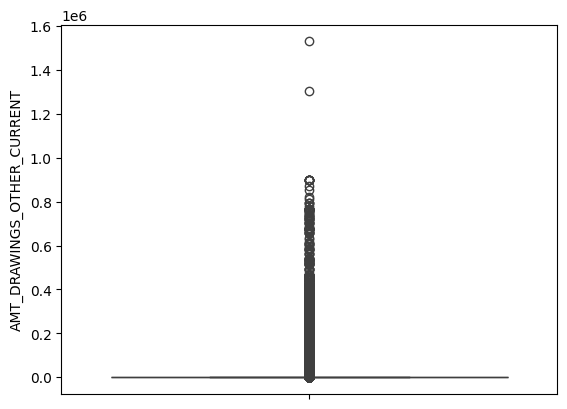

Column: AMT_DRAWINGS_POS_CURRENT


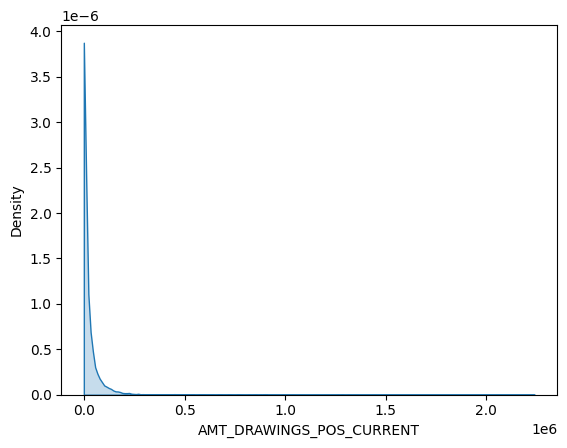

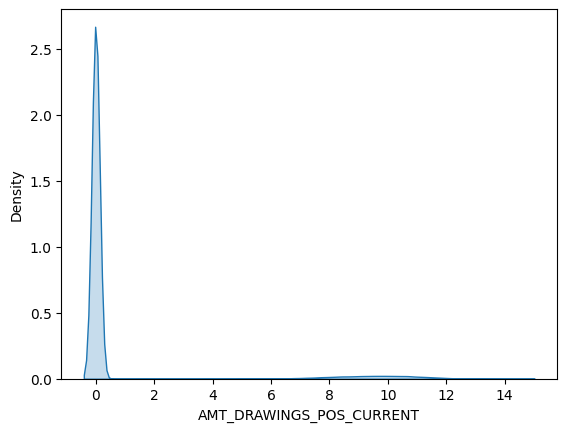

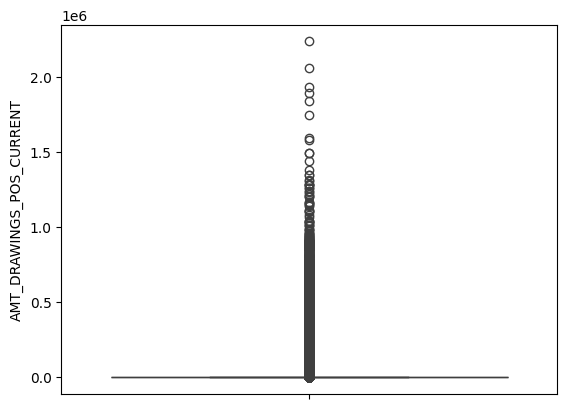

Column: AMT_INST_MIN_REGULARITY


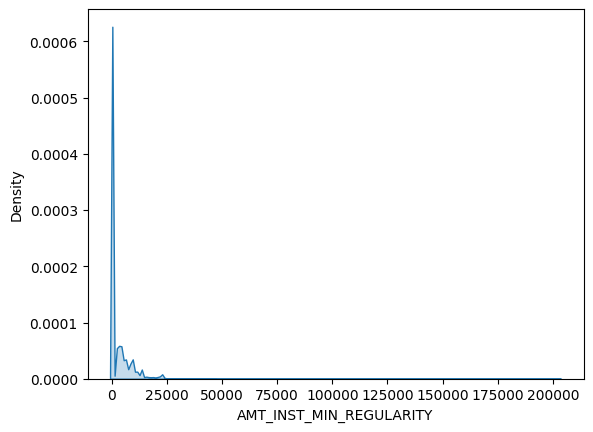

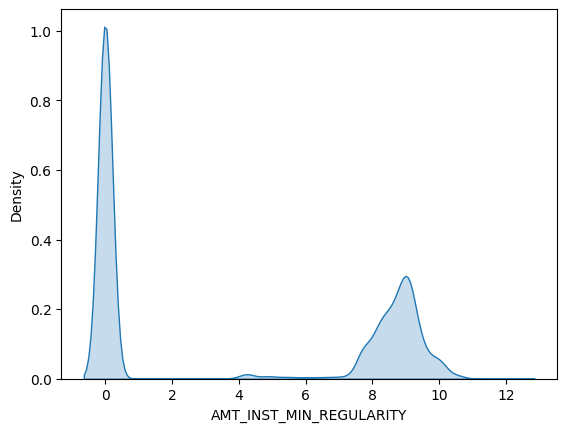

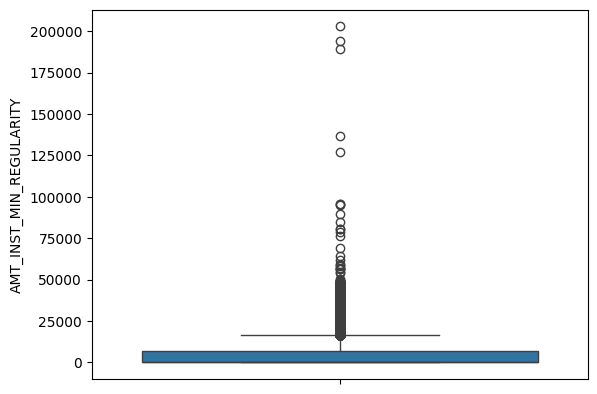

Column: AMT_PAYMENT_CURRENT


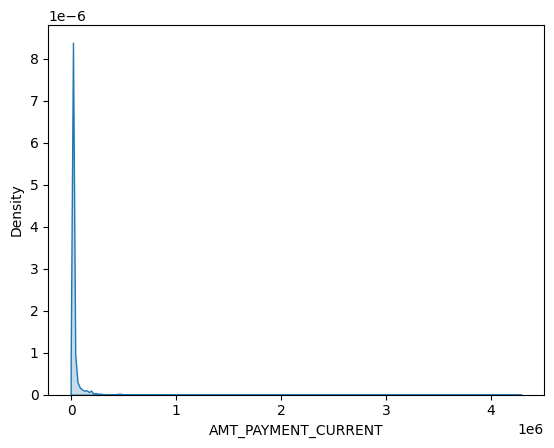

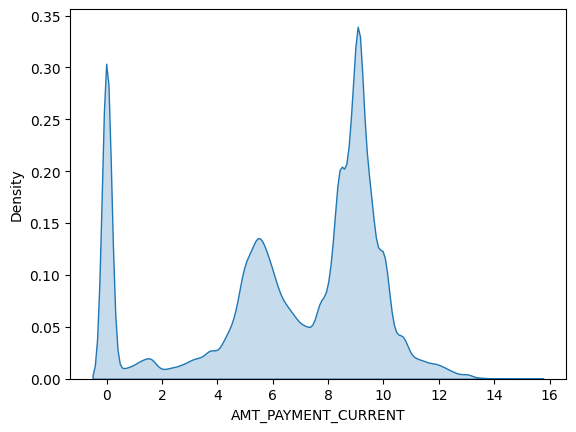

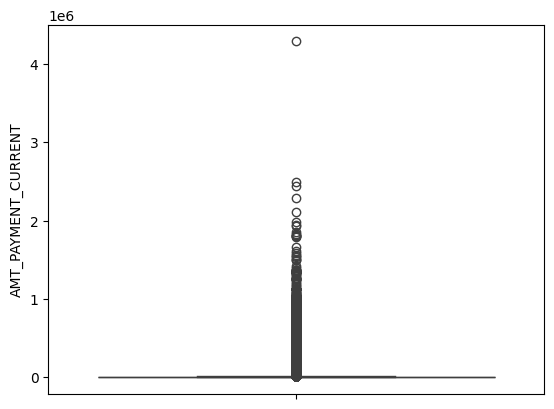

Column: AMT_PAYMENT_TOTAL_CURRENT


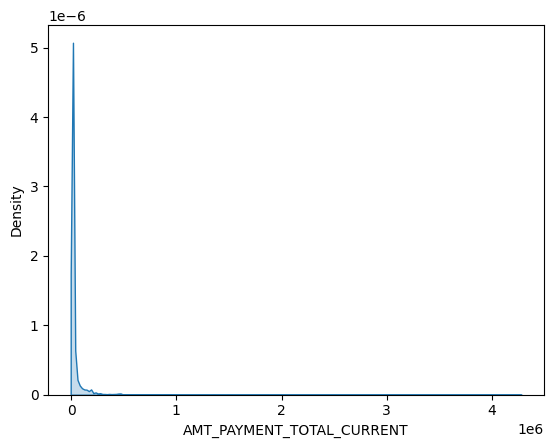

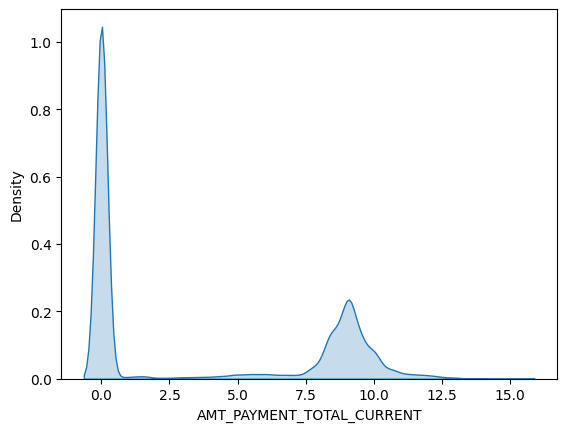

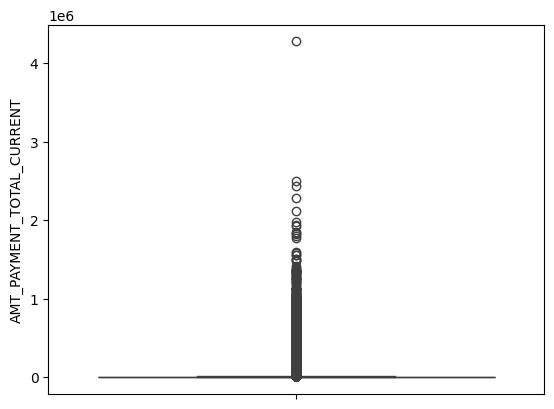

Column: AMT_RECEIVABLE_PRINCIPAL


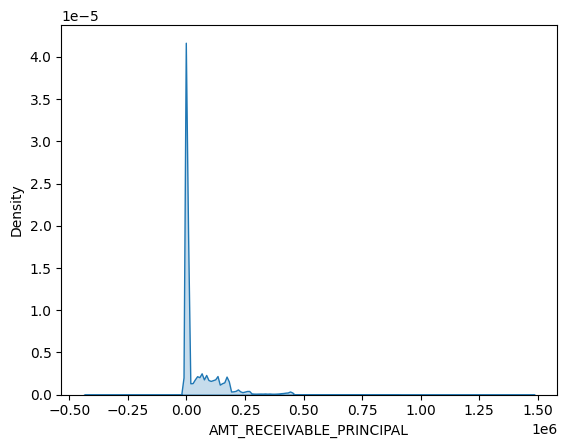

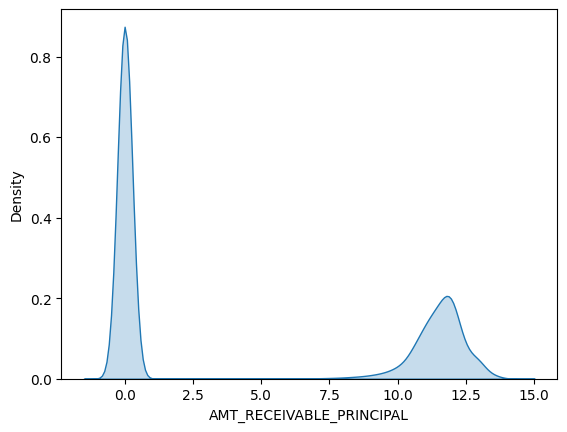

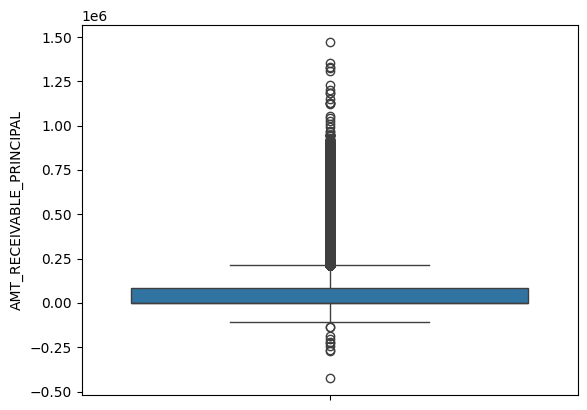

Column: AMT_RECIVABLE


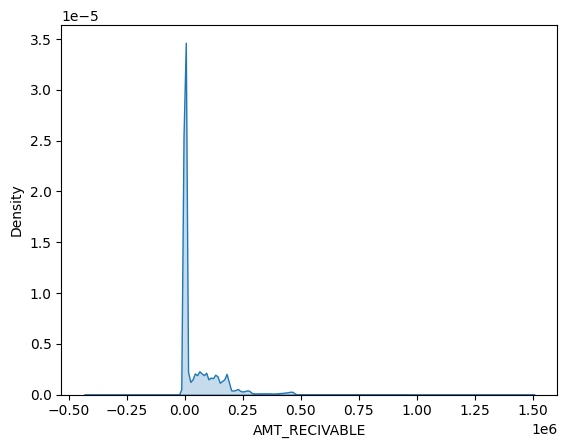

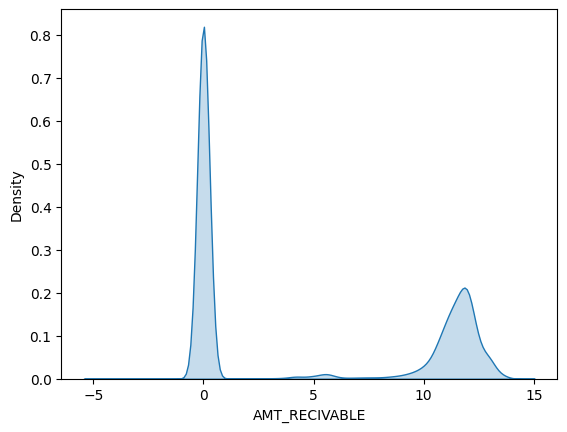

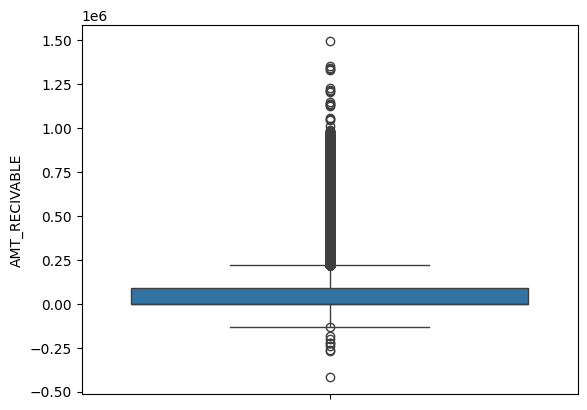

Column: AMT_TOTAL_RECEIVABLE


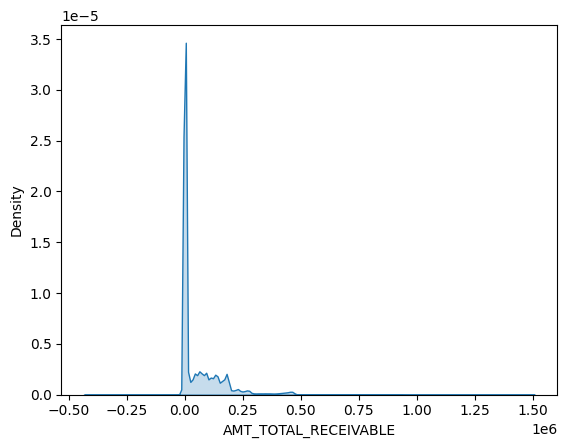

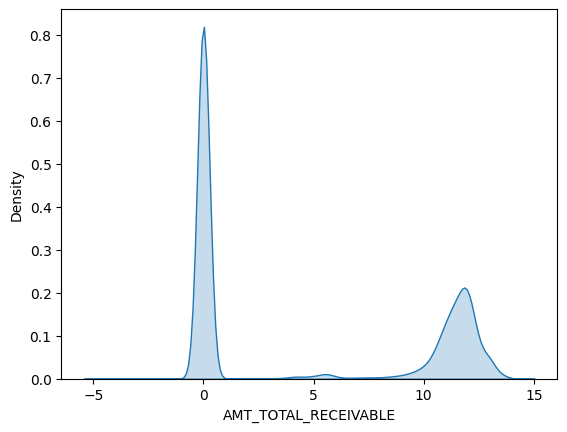

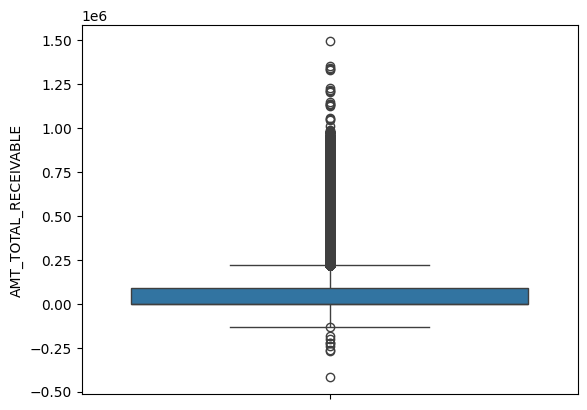

Column: CNT_DRAWINGS_ATM_CURRENT


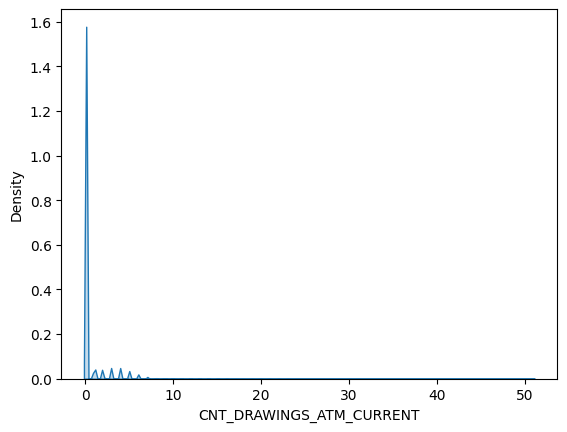

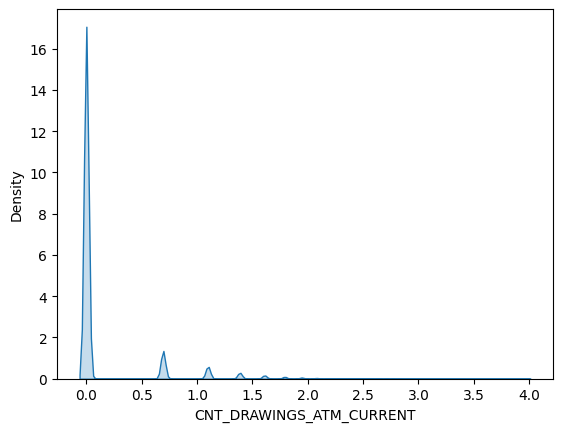

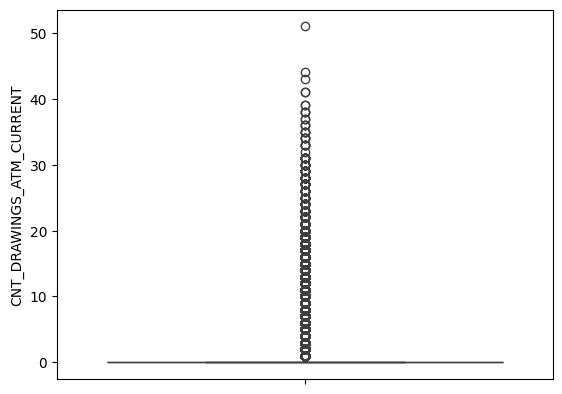

Column: CNT_DRAWINGS_OTHER_CURRENT


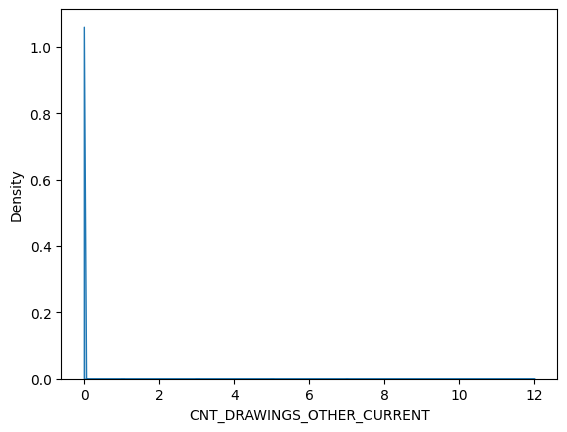

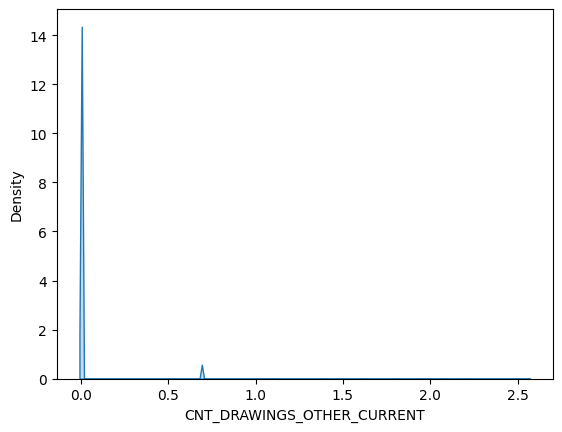

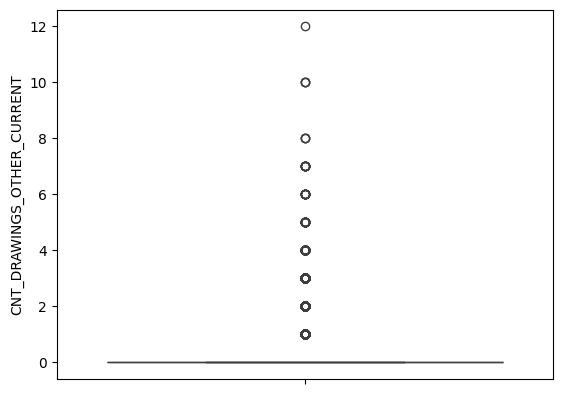

Column: CNT_DRAWINGS_POS_CURRENT


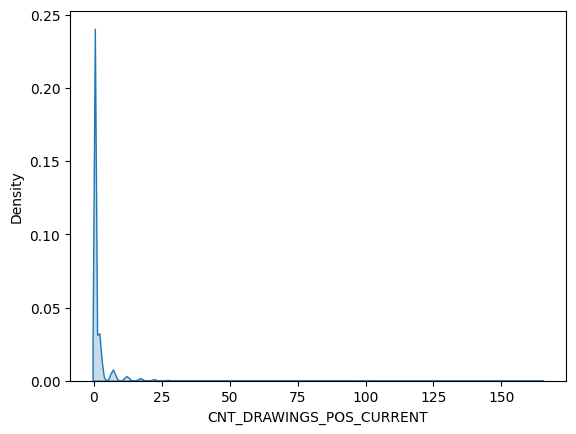

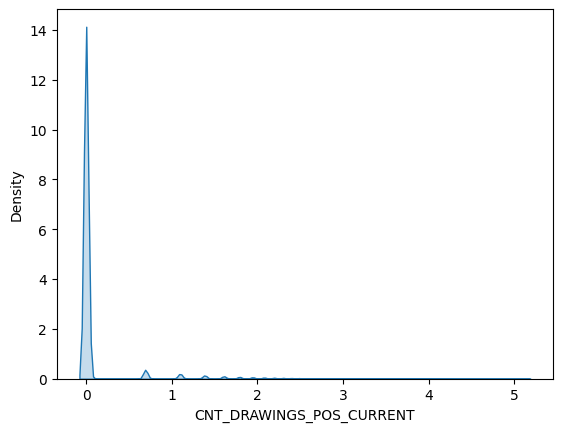

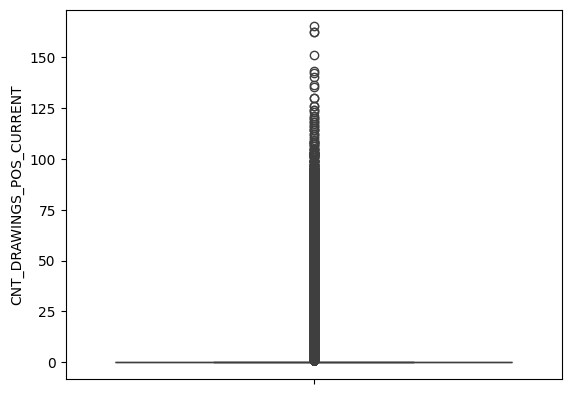

Column: CNT_INSTALMENT_MATURE_CUM


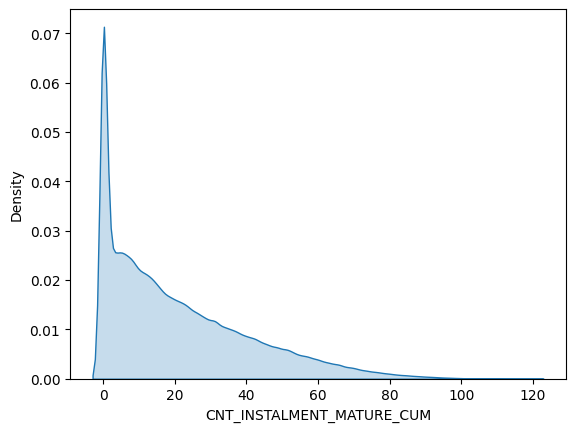

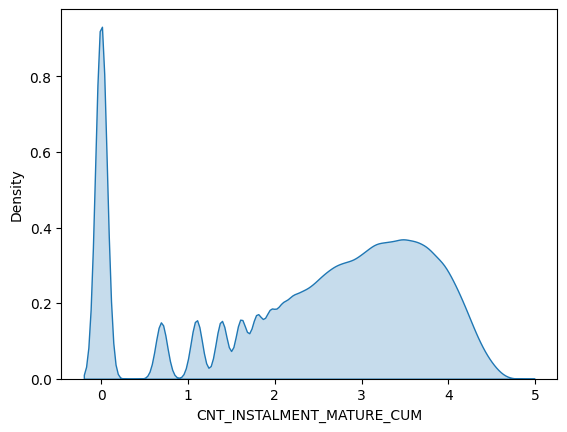

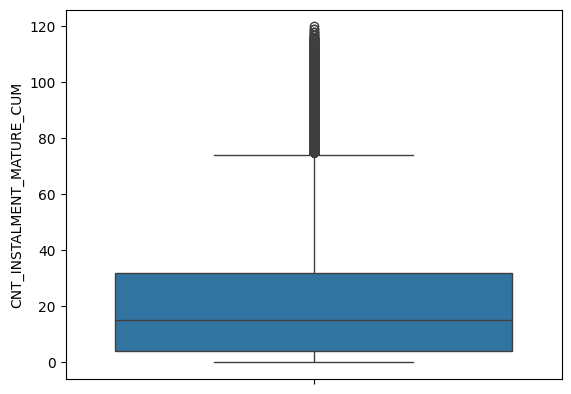

In [82]:
for col in [col for col in credit_card_balance.columns.values if str(credit_card_balance[col].dtype).startswith('float')]:
    print(f'Column: {col}')
    sns.kdeplot(credit_card_balance, x=col, fill=True)
    plt.show()

    sns.kdeplot(np.log1p(credit_card_balance[col]), fill=True)
    plt.show()
    
    sns.boxplot(credit_card_balance, y=col)
    plt.show()
    print('=' * 50)

#### Что видно:
1. Очень много значений которые выходят из диапазона q1-q3. 
2. На некоторых графиках самая высокая точка в 0. Так должно быть или наны просто 0 заменили?

In [83]:
credit_card_balance['AMT_TOTAL_RECEIVABLE'].value_counts()

AMT_TOTAL_RECEIVABLE
0.000         2113643
67.500           3144
270.000          2301
130.500           825
135.000           756
               ...   
73169.190           1
128204.460          1
34097.130           1
100889.280          1
273093.975          1
Name: count, Length: 1339008, dtype: int64